# AllFigures — Unified Figure Notebook

Single notebook producing all three manuscript figures with minimal redundant computation.
Every trajectory, cost eigenvector, and susceptibility is computed **once** per
(task, realization, subtask) and cached to `.figure_notebook_cache/`.

**Representatives**:
- Global: `data/targeted_results_sqr/task_13/realization_00/`
- Local:  `data/allosteric_nets/geometry_targeted/task_0/realization_0/`

**Figure 1** — Physical proxies: network, response curves, |ψ| vs susceptibility, Spearman ρ histograms.
**Figure 2** — Mode dynamics: overlap heatmap, GIF, Hessian spectrum, participation ratio, sensitivity histogram.
**Figure 3** — Ensemble correlations: scatter plots, heatmaps, Spearman ρ per proxy.


In [1]:
import sys, json, pickle, copy, warnings
from pathlib import Path
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib import collections as mc
from matplotlib.colors import Normalize, LogNorm
from scipy.stats import spearmanr, rankdata
from scipy.sparse.linalg import LinearOperator, eigsh
import jax
import jax.numpy as jnp

jax.config.update('jax_enable_x64', True)

REPO_ROOT = Path('../../../').resolve()
# Add project root so base/, analysis/, training/ packages are importable
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from base.elastic_network import ElasticNetwork
from base.network_utils import get_square_boundary_nodes
from generalized_susceptibility import (
    compute_physical_hessian_strained,
    compute_constrained_hessian_inverse,
    compute_full_jacobian_matrixwise,
    susceptibilities_from_jacobian,
)
from training_functions_with_toggle import (
    crf as _crf,
    compute_quasistatic_trajectory_auxetic,
    compute_poisson_ratio_single_jax,
    make_compute_response_fire,
)

print('JAX devices:', jax.devices())
print('Repo root  :', REPO_ROOT)


JAX devices: [CpuDevice(id=0)]
Repo root  : /Users/fmartins/Library/CloudStorage/Box-Box/PhD/nonlinear_mech_nets


In [2]:
# ── Paths ────────────────────────────────────────────────────────────────────
RESULTS_DIR        = REPO_ROOT / 'data' / 'auxetic_nets' / 'results'
TARGETED_DIR       = REPO_ROOT / 'data' / 'auxetic_nets' / 'targeted_results_sqr'
ALLOSTERIC_DIR     = REPO_ROOT / 'data' / 'allosteric_nets'
ALLOSTERIC_TGT_DIR = REPO_ROOT / 'data' / 'allosteric_nets' / 'geometry_targeted'
CACHE_DIR          = REPO_ROOT / '.figure_notebook_cache'
FIGURE_OUT_DIR     = REPO_ROOT / 'figure_data' / 'allfigs'
CACHE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Representative network IDs ────────────────────────────────────────────────
GLOBAL_TASK_ID = 13
GLOBAL_REAL_ID = 0
LOCAL_TASK_ID  = 0   # geometry_targeted/task_0
LOCAL_REAL_ID  = 0   # realization_0

# ── Computation parameters ────────────────────────────────────────────────────
BOUNDARY_MARGIN   = 0.02
FORCE_TYPE        = 'quadratic'
N_STRAIN_STEPS    = 100   # quasistatic trajectory steps (representative)
N_EQUIL           = 1     # FIRE calls per step
N_MODES_DISPLAY   = 8     # modes shown in overlap heatmap
N_COST_EIGS       = 5     # Lanczos eigenvectors for cost Hessian
HVP_EPSILON       = 1e-4  # finite-difference step for HVP
LOCAL_MAX_STRAIN  = 1.0   # local trajectory max input strain
LOCAL_STRAIN2     = 0.5   # half-strain subtask
N_sub_l           = 2     # two subtasks per local realization
N_TRAJ_STEPS_BULK = 100    # shorter trajectory for bulk mode-sensitivity
MID_FRAME_BULK    = 10    # frame for bulk S_shift / sensitivity evaluation

# ── Cache bypass flag ────────────────────────────────────────────────────────
FORCE_RECOMPUTE = False

# ── Targeted tasks to show for response curves (Figure 1) ────────────────────
GLOBAL_RESPONSE_TASKS = np.arange(23)

# ── Visualization strains for Figure 2 snapshots ─────────────────────────────
LOCAL_STRAINS_TO_PLOT  = [0.1, 0.5, 1.0]
LOCAL_MODES_TO_PLOT    = [1,   2,   1  ]
GLOBAL_STRAINS_TO_PLOT = [0, 0.07, 0.15, 0.22]
GLOBAL_MODES_TO_PLOT   = [8,    1,    1,   3]

print('Configuration loaded.')


Configuration loaded.


In [3]:
def _cache_path(key):
    return CACHE_DIR / f'{key}.npz'

def cache_exists(key):
    return _cache_path(key).exists() and not FORCE_RECOMPUTE

def load_cache(key):
    return dict(np.load(_cache_path(key), allow_pickle=True))

def save_cache(key, **arrays):
    np.savez(_cache_path(key), **arrays)

print('Cache helpers defined.')


Cache helpers defined.


In [4]:
def incmat_to_edges(incmat):
    """(E, N) incidence matrix → (E, 2) edge array."""
    edges = np.zeros((len(incmat), 2), dtype=int)
    for e, row in enumerate(incmat):
        cols = np.where(np.abs(row) > 0.5)[0]
        edges[e, 0] = int(cols[0])
        edges[e, 1] = int(cols[1])
    return edges

def free_dofs_local(N):
    """Free DOF indices for local task: exclude input nodes 0 and 1."""
    return np.arange(4, 2 * N)

def free_dofs_global(N, top_nodes, bottom_nodes):
    """Free DOF indices for global task: exclude top/bottom boundary nodes."""
    constrained = np.unique(np.concatenate([
        np.asarray(top_nodes,    dtype=int),
        np.asarray(bottom_nodes, dtype=int),
    ]))
    free_nodes = np.setdiff1d(np.arange(N), constrained)
    return np.sort(np.concatenate([2 * free_nodes, 2 * free_nodes + 1]))

def build_incidence_matrix(edges, n_nodes):
    E = len(edges)
    B = np.zeros((E, n_nodes), dtype=float)
    for e, (i, j) in enumerate(edges):
        B[e, i] = +1.0
        B[e, j] = -1.0
    return B

def bond_strain_stress(positions, edges, k, L0):
    """Per-edge strain and stress. Returns (strain, stress) each (E,)."""
    d = positions[edges[:, 0]] - positions[edges[:, 1]]
    ell = np.linalg.norm(d, axis=1)
    strain = (ell - L0) / L0
    stress = k * strain
    return strain, stress

print('Geometry helpers defined.')


Geometry helpers defined.


In [5]:
def _sibling_realization_dirs(task_parent, own_dir):
    """Yield realization subdirectories of task_parent, own_dir first, then others sorted."""
    if not task_parent.is_dir():
        return
    yield own_dir
    for rd in sorted(task_parent.iterdir()):
        if rd.is_dir() and rd != own_dir:
            yield rd


def _geometry_realization_dirs(geom_dir, own_task_parent, own_dir):
    """Yield all realization dirs under geom_dir: own_dir, then same-task siblings, then other tasks."""
    yield own_dir
    for rd in sorted(own_task_parent.iterdir()):
        if rd.is_dir() and rd != own_dir:
            yield rd
    for td in sorted(geom_dir.iterdir()):
        if td.is_dir() and td != own_task_parent:
            for rd in sorted(td.iterdir()):
                if rd.is_dir():
                    yield rd


# ── Global network loader ─────────────────────────────────────────────────────
def load_global_network(task_seed, real_seed, data_dir=None, task_config=None):
    """Load ElasticNetwork + boundary_dict + task_config for a global task.

    Stiffnesses: own realization only (never substitute from another).
    Positions, edges, rest_lengths: own realization first, then sibling fallback.
    task_config.json: use task_config if provided, else own first, then siblings.
    """
    if data_dir is None:
        data_dir = RESULTS_DIR
    task_parent = data_dir / f'task_{task_seed:02d}'
    own         = task_parent / f'realization_{real_seed:02d}'

    # Load own pkl for stiffnesses (required — no fallback)
    with open(own / 'final_network.pkl', 'rb') as fh:
        net = pickle.load(fh)
    stiffnesses = np.array(net['stiffnesses'], dtype=float)

    # Topology (positions, edges, rest_lengths): own first, then sibling realizations
    positions    = np.array(net['positions'],    dtype=float)    if net.get('positions')    is not None else None
    edges        = np.array(net['edges'],        dtype=int)      if net.get('edges')        is not None else None
    rest_lengths = np.array(net['rest_lengths'], dtype=float)    if net.get('rest_lengths') is not None else None

    if positions is None or edges is None:
        for rd in _sibling_realization_dirs(task_parent, own):
            if rd == own:
                continue
            try:
                with open(rd / 'final_network.pkl', 'rb') as fh:
                    alt = pickle.load(fh)
                if positions    is None and alt.get('positions')    is not None:
                    positions    = np.array(alt['positions'],    dtype=float)
                if edges        is None and alt.get('edges')        is not None:
                    edges        = np.array(alt['edges'],        dtype=int)
                if rest_lengths is None and alt.get('rest_lengths') is not None:
                    rest_lengths = np.array(alt['rest_lengths'], dtype=float)
                if positions is not None and edges is not None:
                    break
            except (FileNotFoundError, KeyError):
                continue

    if positions is None:
        raise RuntimeError(f'No positions found for global task {task_seed}')
    if edges is None:
        raise RuntimeError(f'No edges found for global task {task_seed}')
    if rest_lengths is None:
        d = positions[edges[:, 0]] - positions[edges[:, 1]]
        rest_lengths = np.linalg.norm(d, axis=1)

    top, bottom, left, right = get_square_boundary_nodes(positions, BOUNDARY_MARGIN)
    boundary = dict(top=top, bottom=bottom, left=left, right=right)

    # task_config.json: use pre-scanned value if provided, else search siblings
    config = task_config
    if config is None:
        for rd in _sibling_realization_dirs(task_parent, own):
            cfg_path = rd / 'task_config.json'
            if cfg_path.exists():
                with open(cfg_path) as fh:
                    config = json.load(fh)
                if config:
                    break
    if config is None:
        raise RuntimeError(f'No task_config.json found for global task {task_seed}')

    network = ElasticNetwork(positions, edges, rest_lengths, stiffnesses)
    return network, boundary, config


# ── Local network loader ──────────────────────────────────────────────────────
def load_local_network(geometry_id, task_id, real_id, data_dir=None):
    """Load local (allosteric) network.

    Stiffnesses, eq_lengths: own realization only (return None if missing).
    nodes.npy, incidence_matrix.npy: geometry-level fallback — own realization
      first, then sibling realizations of the same task, then all other tasks
      in the same geometry (geometry_id must not be None for the latter).
    tasks.txt: task-level fallback — own realization first, then sibling
      realizations of the same task only.

    Returns dict with keys: nodes, edges, incmat, stiffnesses, eq_lengths,
                            strain_input, target_output, free_dofs
    Returns None if stiffnesses or eq_lengths are missing.
    """
    if data_dir is None:
        data_dir = ALLOSTERIC_DIR

    if geometry_id is None:
        task_parent = data_dir / f'task_{task_id}'
        task_dir    = task_parent / f'realization_{real_id}'
        geom_dir    = None
    else:
        task_parent = data_dir / f'geometry_{geometry_id}' / f'task_{task_id}'
        task_dir    = task_parent / f'realization_{real_id}'
        geom_dir    = task_parent.parent

    # Stiffnesses — realization-specific, no fallback
    if not (task_dir / 'stiffnesses.npy').exists():
        return None
    try:
        stiffnesses = np.abs(np.load(task_dir / 'stiffnesses.npy').astype(float))
    except Exception:
        return None

    # Equilibrium lengths — realization-specific, no fallback
    if not (task_dir / 'eq_lengths.npy').exists():
        return None
    try:
        L0 = np.load(task_dir / 'eq_lengths.npy').astype(float)
    except Exception:
        return None

    # Topology (geometry-level): geometry-wide fallback when geometry_id is set,
    # otherwise fall back to sibling realizations of the same task only.
    nodes = incmat = None
    geom_iter = (
        _geometry_realization_dirs(geom_dir, task_parent, task_dir)
        if geom_dir is not None
        else _sibling_realization_dirs(task_parent, task_dir)
    )
    for rd in geom_iter:
        if nodes is None and (rd / 'nodes.npy').exists():
            try:
                nodes = np.load(rd / 'nodes.npy').astype(float)
            except Exception:
                pass
        if incmat is None and (rd / 'incidence_matrix.npy').exists():
            try:
                incmat = np.load(rd / 'incidence_matrix.npy')
            except Exception:
                pass
        if nodes is not None and incmat is not None:
            break

    # Task config (task-level): sibling realizations of the same task only.
    task_vals = None
    for rd in _sibling_realization_dirs(task_parent, task_dir):
        if (rd / 'tasks.txt').exists():
            try:
                task_vals = np.loadtxt(rd / 'tasks.txt')
            except Exception:
                pass
        if task_vals is not None:
            break

    if nodes is None or incmat is None or task_vals is None:
        return None

    edges = incmat_to_edges(incmat)
    N     = nodes.shape[0]
    fdofs = free_dofs_local(N)

    # tasks.txt format: [geometry_seed, strain_output2, strain_output]
    target_output  = float(np.abs(task_vals[2]))   # at full strain (LOCAL_MAX_STRAIN)
    target_output2 = float(np.abs(task_vals[1]))   # at half strain (LOCAL_STRAIN2)

    return dict(
        nodes=nodes, edges=edges, incmat=incmat,
        stiffnesses=stiffnesses, eq_lengths=L0,
        strain_input=LOCAL_MAX_STRAIN,  target_output=target_output,
        strain_input2=LOCAL_STRAIN2,    target_output2=target_output2,
        free_dofs=fdofs, N=N,
        geometry_id=geometry_id, task_id=task_id, real_id=real_id,
    )


def load_local_targeted(task_id, real_id):
    """Load local targeted network from geometry_targeted."""
    return load_local_network(None, task_id, real_id, data_dir=ALLOSTERIC_TGT_DIR)


print('Data loading functions defined.')


Data loading functions defined.


In [6]:
def compute_global_traj(network, compression_strain, boundary, n_steps=N_STRAIN_STEPS):
    """Quasistatic trajectory for global (Poisson) task. Returns list of (N,2) arrays."""
    net_copy = copy.deepcopy(network)
    return compute_quasistatic_trajectory_auxetic(
        net_copy, compression_strain,
        boundary['top'], boundary['bottom'],
        n_steps=n_steps, verbose=False,
        force_type=FORCE_TYPE, tol=1e-9,
    )


def compute_local_traj(net_dict, max_strain=LOCAL_MAX_STRAIN, n_steps=N_STRAIN_STEPS):
    """Quasistatic local trajectory via crf. Returns list of (N,2) arrays.

    Node 0 is fixed; node 1 is displaced along x by (strain * d0).
    Source DOF order: [x_node0, x_node1, y_node0, y_node1].
    """
    nodes0   = net_dict['nodes']
    edges_j  = jnp.asarray(net_dict['edges'],      dtype=jnp.int32)
    eq_j     = jnp.asarray(net_dict['eq_lengths'])
    k_j      = jnp.asarray(net_dict['stiffnesses'])

    x0,  y0  = float(nodes0[0, 0]), float(nodes0[0, 1])
    x1i, y1i = float(nodes0[1, 0]), float(nodes0[1, 1])
    d0        = float(np.linalg.norm(nodes0[1] - nodes0[0]))
    src_dof   = jnp.array([0, 2, 1, 3], dtype=jnp.int32)  # x0,x1,y0,y1

    traj = [nodes0.copy()]
    pos  = jnp.asarray(nodes0.flatten())
    for step in range(n_steps):
        target  = (step + 1) / n_steps * max_strain
        imposed = jnp.array([x0, x1i + target * d0, y0, y1i])
        for _ in range(N_EQUIL):
            pos = _crf(k_j, edges_j, eq_j, pos, src_dof, imposed)
        traj.append(np.array(pos).reshape(-1, 2))
    return traj


print('Trajectory functions defined.')


Trajectory functions defined.


In [7]:
def compute_susceptibilities(positions, edges, k, L0, constrained_nodes):
    """s_par, s_perp, s_eq, s_tot per edge. All (E,) arrays."""
    H_inv = compute_constrained_hessian_inverse(
        positions, edges, k, L0, constrained_nodes)
    _, Hjac_parts, _ = compute_full_jacobian_matrixwise(
        positions, edges, k, L0,
        H_ff_inv=None, H_full_inv=H_inv)
    s_par, s_perp, s_eq, s_tot = susceptibilities_from_jacobian(Hjac_parts)
    return (np.asarray(s_par,  dtype=float),
            np.asarray(s_perp, dtype=float),
            np.asarray(s_eq,   dtype=float),
            np.asarray(s_tot,  dtype=float))


def compute_s_shift(positions, edges, k, L0, fdofs):
    """S_shift = ||H_ff^{-1} J[:,e]||_2 per edge.

    J_{2a,e}   = -(ell_e - L0_e) * B[e,a] * nhat_e[x]   (absolute extension)
    J_{2a+1,e} = -(ell_e - L0_e) * B[e,a] * nhat_e[y]

    Source: notebooks/analysis/s_shift_susceptibility_analysis.ipynb
    """
    positions = np.asarray(positions, dtype=float)
    n_nodes   = positions.shape[0]
    E         = len(edges)

    B = build_incidence_matrix(edges, n_nodes)         # (E, N)
    disps   = B @ positions                             # (E, 2)
    ells    = np.linalg.norm(disps, axis=1)             # (E,)
    nhats   = disps / ells[:, None]                     # (E, 2)
    stretch = ells - np.asarray(L0)                     # (E,) absolute extension

    # Build Jacobian J: (2N, E)
    J = np.zeros((2 * n_nodes, E), dtype=float)
    J[0::2] = -B.T * (stretch * nhats[:, 0])   # (N, E)
    J[1::2] = -B.T * (stretch * nhats[:, 1])   # (N, E)

    H_full   = compute_physical_hessian_strained(k, L0, edges, positions)
    H_ff     = H_full[np.ix_(fdofs, fdofs)]
    H_ff_inv = np.linalg.inv(H_ff)

    S = H_ff_inv @ J[fdofs]          # (2*N_free, E)
    return np.linalg.norm(S, axis=0) # (E,)


print('Susceptibility functions defined.')


Susceptibility functions defined.


In [8]:
# ── Pre-build a reusable differentiable FIRE solver ───────────────────────────
_crf_diff = make_compute_response_fire(
    d=2, force_type=FORCE_TYPE, max_steps=500_000, tol=1e-8)


def compute_global_cost_evec(network, compression_strain, target_poisson, boundary,
                              n_steps=N_STRAIN_STEPS, k_eigs=N_COST_EIGS):
    """Leading eigenvector of d²L/dk² for global (Poisson) task.
    Loss = (poisson_ratio(k) - target_poisson)²
    Uses JAX finite-difference HVP + Lanczos (eigsh).
    Returns |ψ| shape (n_edges,).
    """
    n_edges = len(network.stiffnesses)
    base_k  = np.array(network.stiffnesses, dtype=float)
    top     = jnp.asarray(np.array(boundary['top'],    dtype=np.int32))
    bot     = jnp.asarray(np.array(boundary['bottom'], dtype=np.int32))
    left    = jnp.asarray(np.array(boundary['left'],   dtype=np.int32))
    right   = jnp.asarray(np.array(boundary['right'],  dtype=np.int32))
    edges_j = jnp.asarray(np.array(network.edges,       dtype=np.int32))
    restl_j = jnp.asarray(np.array(network.rest_lengths, dtype=np.float64))
    pos_j   = jnp.asarray(np.array(network.positions,    dtype=np.float64).flatten())

    def loss_fn(k_jax):
        pr = compute_poisson_ratio_single_jax(
            _crf_diff, k_jax, edges_j, restl_j, pos_j,
            top, bot, left, right, compression_strain, n_steps)
        return (pr - target_poisson) ** 2

    grad_fn = jax.jit(jax.grad(loss_fn))
    g0 = np.array(grad_fn(jnp.asarray(base_k)))

    def hvp(v):
        v  = np.asarray(v, dtype=float)
        nv = float(np.linalg.norm(v))
        if nv < 1e-14:
            return np.zeros(n_edges)
        gf = np.array(grad_fn(jnp.asarray(base_k + HVP_EPSILON * v / nv)))
        return nv * (gf - g0) / HVP_EPSILON

    H_op = LinearOperator((n_edges, n_edges), matvec=hvp, dtype=float)
    k = min(k_eigs, n_edges - 1)
    evals, evecs = eigsh(H_op, k=k, which='LM')
    return np.abs(evecs[:, np.argmax(evals)])


def compute_local_cost_evec(net_dict, k_eigs=N_COST_EIGS,
                              strain_input=None, target_out=None):
    """Leading eigenvector of d²L/dk² for local (allosteric) task.
    Loss = ((d_output(k)/d0_output - 1) - target_output)²
    Returns |ψ| shape (n_edges,).
    strain_input / target_out override net_dict values (for subtask 1).
    """
    positions    = net_dict['nodes']
    edges        = net_dict['edges']
    stiffnesses  = net_dict['stiffnesses']
    rest_lengths = net_dict['eq_lengths']
    if strain_input is None: strain_input = net_dict['strain_input']
    if target_out   is None: target_out   = net_dict['target_output']
    n_steps      = N_STRAIN_STEPS

    base_k   = jnp.asarray(np.abs(np.array(stiffnesses, dtype=float)))
    edges_j  = jnp.asarray(np.array(edges,       dtype=np.int32))
    restl_j  = jnp.asarray(np.array(rest_lengths, dtype=np.float64))
    pos_j    = jnp.asarray(np.array(positions,    dtype=np.float64).flatten())
    E        = int(base_k.shape[0])

    x0,  y0  = float(positions[0, 0]), float(positions[0, 1])
    x1i, y1i = float(positions[1, 0]), float(positions[1, 1])
    d0        = float(np.linalg.norm(positions[1] - positions[0]))
    d23_0     = float(np.linalg.norm(positions[3] - positions[2]))
    src_dof   = jnp.array([0, 2, 1, 3], dtype=jnp.int32)

    def loss_fn(k):
        cur = pos_j
        for step in range(n_steps):
            frac    = (step + 1) / n_steps
            imposed = jnp.array([x0, x1i + frac * strain_input * d0, y0, y1i])
            cur     = _crf_diff(k, edges_j, restl_j, cur, src_dof, imposed)
        eq = cur.reshape(-1, 2)
        d23 = jnp.linalg.norm(eq[3] - eq[2])
        return ((d23 - d23_0) / d23_0 - target_out) ** 2

    grad_fn = jax.jit(jax.grad(loss_fn))
    g0 = np.array(grad_fn(base_k))

    def hvp(v):
        v  = np.asarray(v, dtype=float)
        nv = float(np.linalg.norm(v))
        if nv < 1e-14:
            return np.zeros(E)
        gf = np.array(grad_fn(base_k + HVP_EPSILON * v / nv))
        return nv * (gf - g0) / HVP_EPSILON

    H_op = LinearOperator((E, E), matvec=hvp, dtype=float)
    k = min(k_eigs, E - 1)
    _, evecs = eigsh(H_op, k=k, which='LA', maxiter=300, tol=1e-5)
    return np.abs(evecs[:, -1])


print('Cost eigenvector functions defined.')


Cost eigenvector functions defined.


In [9]:
def hessian_modes(positions, stiffnesses, eq_lengths, edges, fdofs):
    """Free-node Hessian eigenvalues (ascending) and eigenvectors.
    Returns (vals (M,), vecs_T (M, M)) where rows of vecs_T are eigenvectors.
    """
    H      = compute_physical_hessian_strained(stiffnesses, eq_lengths, edges, positions)
    H_free = H[np.ix_(fdofs, fdofs)]
    vals, vecs = np.linalg.eigh(H_free)
    return vals, vecs.T   # rows = eigenvectors


def compute_analysis(traj, stiffnesses, eq_lengths, edges, fdofs, verbose=True):
    """Hessian spectrum and mode overlaps along a quasistatic trajectory.

    Returns
    -------
    spectrum : (T, M)   eigenvalues at each frame
    overlaps : (T-1, M) signed cosine overlap  e_k · δu_hat  (free DOFs)
    """
    T = len(traj)
    M = len(fdofs)
    spectrum = np.zeros((T, M))
    overlaps = np.zeros((T - 1, M))

    for t in range(T):
        vals, vecs_T = hessian_modes(traj[t], stiffnesses, eq_lengths, edges, fdofs)
        spectrum[t]  = vals
        if t < T - 1:
            dr  = (traj[t + 1] - traj[t]).ravel()[fdofs]
            nrm = float(np.linalg.norm(dr))
            if nrm > 1e-12:
                overlaps[t] = vecs_T @ (dr / nrm)
        if verbose and (t + 1) % 25 == 0:
            print(f'    frame {t + 1}/{T}', flush=True)

    return spectrum, overlaps


def participation_ratio(overlaps):
    """PR[t] = (sum_m overlap[t,m]^4)^{-1} (effective mode count)."""
    o4 = overlaps ** 4
    denom = o4.sum(axis=1)
    with np.errstate(divide='ignore', invalid='ignore'):
        return np.where(denom > 0, 1.0 / denom, np.nan)


def compute_mode_sensitivity(stiffnesses_np, pos_t, pos_t1, fdofs_np, edges_np, eq_lengths_np):
    """Jacobian d(c_k)/d(k_i), shape (M, E).

    Uses JAX Jacobian of the per-mode overlap with the displacement direction.
    Positions pos_t and pos_t1 treated as fixed constants.
    """
    N      = pos_t.shape[0]
    E      = len(stiffnesses_np)
    edges_a = np.asarray(edges_np, dtype=int)

    B = build_incidence_matrix(edges_a, N)
    disps = B @ pos_t
    ells  = np.linalg.norm(disps, axis=1)
    nhats = disps / ells[:, None]
    fs    = 1.0 - np.asarray(eq_lengths_np) / ells

    dr     = (pos_t1 - pos_t).ravel()[fdofs_np]
    nrm    = float(np.linalg.norm(dr))
    if nrm < 1e-12:
        return np.zeros((len(fdofs_np), E))
    dr_hat = dr / nrm

    nhats_j  = jnp.array(nhats)
    fs_j     = jnp.array(fs)
    B_j      = jnp.array(B)
    dr_hat_j = jnp.array(dr_hat)
    fdofs_a  = np.asarray(fdofs_np, dtype=int)

    def overlaps_fn(k):
        odiags1 = jnp.einsum('im,in->imn', nhats_j, nhats_j)
        odiags  = (odiags1
                   + jnp.einsum('i,mn->imn', fs_j, jnp.eye(2))
                   - jnp.einsum('i,imn->imn', fs_j, odiags1))
        H_flat  = jnp.einsum('i,ia,ib,imn->ambn',
                              k, B_j, B_j, odiags).reshape(2 * N, 2 * N)
        H_free  = H_flat[fdofs_a[:, None], fdofs_a[None, :]]
        _, vecs = jnp.linalg.eigh(H_free)
        return vecs.T @ dr_hat_j   # (M,)

    jac = jax.jacobian(overlaps_fn)(jnp.array(stiffnesses_np, dtype=jnp.float64))
    return np.array(jac)  # (M, E)


print('Mode analysis functions defined.')


Mode analysis functions defined.


In [10]:
def poisson_ratio_along_traj(traj, boundary):
    """Compute Poisson ratio at each frame of a global trajectory.
    Returns (strains, poisson_ratios) as (T,) arrays.
    """
    top, bottom, left, right = (boundary['top'], boundary['bottom'],
                                boundary['left'], boundary['right'])
    pos0     = traj[0]
    h0       = pos0[top, 1].mean() - pos0[bottom, 1].mean()
    w0       = pos0[right, 0].mean() - pos0[left, 0].mean()
    T        = len(traj)
    strains  = np.zeros(T)
    nu_vals  = np.zeros(T)
    for t, pos in enumerate(traj):
        h   = pos[top, 1].mean() - pos[bottom, 1].mean()
        w   = pos[right, 0].mean() - pos[left, 0].mean()
        eps_vert = (h - h0) / h0   # compression = negative
        eps_lat  = (w - w0) / w0
        strains[t] = eps_vert
        nu_vals[t] = -eps_lat / eps_vert if abs(eps_vert) > 1e-10 else 0.0
    return strains, nu_vals


def output_strain_along_traj(traj, edges, L0):
    """Output strain (edge 2-3 relative length change) along local trajectory.
    Returns (input_fracs, output_strains).
    Edge between nodes 2,3 treated as the output edge.
    """
    T       = len(traj)
    pos0    = traj[0]
    d23_0   = np.linalg.norm(pos0[3] - pos0[2])
    out_s   = np.zeros(T)
    inp_f   = np.linspace(0, 1, T)
    for t, pos in enumerate(traj):
        d23      = np.linalg.norm(pos[3] - pos[2])
        out_s[t] = (d23 - d23_0) / d23_0
    return inp_f, out_s


print('Response curve helpers defined.')


Response curve helpers defined.


In [11]:
def draw_network(ax, positions, edges, values, cmap='Greys_r',
                 vmin=None, vmax=None, lw=1.5, alpha=0.9,
                 highlight_nodes=None, highlight_colors=None, highlight_size=40):
    """Draw network with edges colored by `values` (log10 scale)."""
    log_v = np.log10(np.abs(values) + 1e-14)
    if vmin is None: vmin = np.nanpercentile(log_v, 2)
    if vmax is None: vmax = np.nanpercentile(log_v, 98)
    norm = Normalize(vmin=vmin, vmax=vmax)
    cm   = plt.get_cmap(cmap)
    segs = [positions[e] for e in edges]
    cols = [cm(norm(v)) for v in log_v]
    lc   = mc.LineCollection(segs, colors=cols, linewidths=lw, alpha=alpha)
    ax.add_collection(lc)
    ax.set_xlim(positions[:, 0].min() - 0.05, positions[:, 0].max() + 0.05)
    ax.set_ylim(positions[:, 1].min() - 0.05, positions[:, 1].max() + 0.05)
    ax.set_aspect('equal')
    if highlight_nodes is not None:
        for nodes, color in zip(highlight_nodes, highlight_colors or ['red'] * len(highlight_nodes)):
            ax.scatter(positions[nodes, 0], positions[nodes, 1],
                       s=highlight_size, c=color, zorder=5)
    return lc


def draw_mode_quiver(ax, positions, evec, scale=None, color='C0', alpha=0.8):
    """Draw eigenvector as quiver arrows on node positions."""
    N    = positions.shape[0]
    mode = np.asarray(evec).reshape(N, 2)
    if scale is None:
        mx = np.linalg.norm(mode, axis=1).max()
        scale = mx * 10 + 1e-12
    ax.quiver(positions[:, 0], positions[:, 1],
              mode[:, 0], mode[:, 1],
              scale=scale, color=color, alpha=alpha, width=0.005)


def make_actuation_gif(traj, spectrum, overlaps, positions0, edges, stiffnesses,
                       fdofs, outpath, fps=12, n_modes_show=1):
    """Side-by-side GIF: left = deforming network, right = dominant mode quiver."""
    T = len(traj)
    fig, (ax_net, ax_mode) = plt.subplots(1, 2, figsize=(10, 5))
    fig.tight_layout(pad=1.5)

    def init():
        ax_net.clear(); ax_mode.clear()
        return []

    def update(t):
        ax_net.clear(); ax_mode.clear()
        pos = np.array(traj[t])
        draw_network(ax_net, pos, edges, stiffnesses, cmap='Greys_r')
        ax_net.set_title(f'Frame {t}/{T-1}', fontsize=10)
        ax_net.axis('off')

        if t < len(overlaps):
            dom = int(np.argmax(np.abs(overlaps[t])))
        else:
            dom = 0
        vals, vecs_T = hessian_modes(pos, stiffnesses, np.ones(len(edges)), edges, fdofs)
        evec_full = np.zeros(2 * pos.shape[0])
        evec_full[fdofs] = vecs_T[dom]
        draw_mode_quiver(ax_mode, pos, evec_full, color='C0')
        draw_network(ax_mode, pos, edges, stiffnesses, cmap='Greys_r', alpha=0.3)
        ax_mode.set_title(f'Mode {dom+1}', fontsize=10)
        ax_mode.axis('off')
        return []

    anim = animation.FuncAnimation(fig, update, init_func=init,
                                   frames=T, interval=1000 // fps, blit=False)
    writer = animation.PillowWriter(fps=fps)
    anim.save(str(outpath), writer=writer)
    plt.close(fig)
    print(f'GIF saved → {outpath}')


def find_frame(target_strain, strain_vals):
    """Find the frame index closest to target_strain in strain_vals array."""
    return int(np.argmin(np.abs(np.asarray(strain_vals) - target_strain)))


def spearman_rho(x, y):
    """Spearman ρ between 1-D arrays x and y."""    
    rho, _ = spearmanr(x, y)
    return float(rho)


print('Visualization helpers defined.')


Visualization helpers defined.


## Section A — Compute All Data (Cached)

Loops over all tasks/realizations, computes trajectories, susceptibilities,
S_shift, cost eigenvectors, and (for the bulk) mode sensitivity norms.
All results are stored in `.figure_notebook_cache/`.


In [12]:
from IPython.display import clear_output

print('=== Global non-targeted ensemble (data/results/) ===')
global_nt_records = []   # list of dicts, one per (task, real, subtask)

for task_dir in sorted(RESULTS_DIR.glob('task_*')):
    t = int(task_dir.name.split('_')[1])
    real_dirs = sorted(
        [d for d in task_dir.iterdir() if d.is_dir() and d.name.startswith('realization_')]
    )

    # Pre-scan: find task_config.json from any realization of this task
    task_cfg = None
    for rd in real_dirs:
        cfg_path = rd / 'task_config.json'
        if cfg_path.exists():
            with open(cfg_path) as fh:
                c = json.load(fh)
            if c:
                task_cfg = c
                break
    if task_cfg is None:
        print(f'  task_{t:02d}: no task_config.json in any realization, skipping task')
        continue

    for real_dir in real_dirs:
        r = int(real_dir.name.split('_')[1])
        if not (real_dir / 'training_complete.txt').exists():
            continue

        key = f'global_nt_t{t:02d}_r{r:02d}'
        if cache_exists(key):
            d = load_cache(key)
            for si in range(int(d['n_subtasks'])):
                global_nt_records.append({
                    'task': t, 'real': r, 'subtask': si,
                    's_par':       d[f'si{si}_s_par'],
                    's_perp':      d[f'si{si}_s_perp'],
                    's_eq':        d[f'si{si}_s_eq'],
                    's_tot':       d[f'si{si}_s_tot'],
                    's_shift':     d[f'si{si}_s_shift'],
                    'bond_strain': d[f'si{si}_bond_strain'],
                    'bond_stress': d[f'si{si}_bond_stress'],
                    'stiffnesses': d['stiffnesses'],
                    'psi':         d[f'si{si}_psi'],
                    'compression_strain': float(d[f'si{si}_compression_strain']),
                })
            continue

        try:
            network, boundary, config = load_global_network(t, r, task_config=task_cfg)
        except Exception as e:
            print(f'  task_{t:02d}/real_{r:02d}: load error — {e}')
            continue

        comp_strains   = config['compression_strains']
        target_poisons = config['target_poisson_ratios']
        n_sub          = len(comp_strains)

        save_dict = {'n_subtasks': np.array(n_sub), 'stiffnesses': network.stiffnesses}
        subtask_results = []

        for si, (cs, tp) in enumerate(zip(comp_strains, target_poisons)):
            print(f'  task_{t:02d}/real_{r:02d}/subtask_{si} cs={cs:.3f}... ', end='', flush=True)
            clear_output(wait=True)
            try:
                traj = compute_global_traj(network, cs, boundary)
                pos_end = np.array(traj[-1])
                constrained = np.unique(np.concatenate([boundary['top'], boundary['bottom']]))
                fdofs = free_dofs_global(pos_end.shape[0], boundary['top'], boundary['bottom'])

                s_par, s_perp, s_eq, s_tot = compute_susceptibilities(
                    pos_end, network.edges, network.stiffnesses, network.rest_lengths, constrained)
                s_shift = compute_s_shift(
                    pos_end, network.edges, network.stiffnesses, network.rest_lengths, fdofs)
                b_strain, b_stress = bond_strain_stress(
                    pos_end, network.edges, network.stiffnesses, network.rest_lengths)
                psi = compute_global_cost_evec(network, cs, tp, boundary)

                rho_shift, _ = spearmanr(psi, np.abs(s_shift))
                rho_tot,   _ = spearmanr(psi, np.abs(s_tot))
                print(f'ρ_shift={rho_shift:.3f}  ρ_tot={rho_tot:.3f}')

                save_dict.update({
                    f'si{si}_s_par':             s_par,
                    f'si{si}_s_perp':            s_perp,
                    f'si{si}_s_eq':              s_eq,
                    f'si{si}_s_tot':             s_tot,
                    f'si{si}_s_shift':           s_shift,
                    f'si{si}_bond_strain':       b_strain,
                    f'si{si}_bond_stress':       b_stress,
                    f'si{si}_psi':               psi,
                    f'si{si}_compression_strain': np.array(cs),
                })
                subtask_results.append({
                    'task': t, 'real': r, 'subtask': si,
                    's_par': s_par, 's_perp': s_perp, 's_eq': s_eq, 's_tot': s_tot,
                    's_shift': s_shift, 'bond_strain': b_strain, 'bond_stress': b_stress,
                    'stiffnesses': network.stiffnesses, 'psi': psi, 'compression_strain': cs,
                })
            except Exception as e:
                print(f'FAILED: {e}')

        if subtask_results:
            save_cache(key, **save_dict)
            global_nt_records.extend(subtask_results)

print(f'\nGlobal non-targeted: {len(global_nt_records)} (task, real, subtask) records.')


=== Global non-targeted ensemble (data/results/) ===
  task_03: no task_config.json in any realization, skipping task
  task_25: no task_config.json in any realization, skipping task
  task_27: no task_config.json in any realization, skipping task

Global non-targeted: 720 (task, real, subtask) records.


In [13]:
print('=== Local non-targeted ensemble (data/allosteric_nets/geometry_{0-4}) ===')
local_nt_records = []

for g in range(5):
    geom_dir = ALLOSTERIC_DIR / f'geometry_{g}'
    if not geom_dir.is_dir():
        continue
    for task_dir in sorted(geom_dir.glob('task_*')):
        task_id = int(task_dir.name.split('_')[1])
        for real_dir in sorted(task_dir.glob('realization_*')):
            real_id = int(real_dir.name.split('_')[1])

            key = f'local_nt_g{g}_t{task_id}_r{real_id}'
            if cache_exists(key):
                d = load_cache(key)
                if 'n_subtasks' in d:
                    for si in range(int(d['n_subtasks'])):
                        local_nt_records.append({
                            'geometry': g, 'task': task_id, 'real': real_id, 'subtask': si,
                            's_par':        d[f'si{si}_s_par'],
                            's_perp':       d[f'si{si}_s_perp'],
                            's_eq':         d[f'si{si}_s_eq'],
                            's_tot':        d[f'si{si}_s_tot'],
                            's_shift':      d[f'si{si}_s_shift'],
                            'bond_strain':  d[f'si{si}_bond_strain'],
                            'bond_stress':  d[f'si{si}_bond_stress'],
                            'stiffnesses':  d['stiffnesses'],
                            'psi':          d[f'si{si}_psi'],
                            'target_output': float(d[f'si{si}_target_output']),
                            'strain_input':  float(d[f'si{si}_strain_input']),
                        })
                    continue
                # old single-subtask cache — fall through to recompute

            try:
                net = load_local_network(g, task_id, real_id)
            except Exception as e:
                print(f'  geometry_{g}/task_{task_id}/real_{real_id}: load error — {e}')
                continue
            if net is None:
                continue

            subtask_configs = [
                (net['strain_input'],  net['target_output']),
                (net['strain_input2'], net['target_output2']),
            ]

            save_dict = {'n_subtasks': np.array(N_sub_l), 'stiffnesses': net['stiffnesses']}
            subtask_results = []

            for si, (s_in, t_out) in enumerate(subtask_configs):
                tag = f'  geometry_{g}/task_{task_id}/real_{real_id}/subtask_{si}'
                print(f'{tag} strain={s_in:.1f} target={t_out:.2f}... ', end='', flush=True)
                try:
                    traj    = compute_local_traj(net, max_strain=s_in)
                    pos_end = np.array(traj[-1])
                    fdofs   = net['free_dofs']
                    constrained_nodes = np.array([0, 1], dtype=int)

                    s_par, s_perp, s_eq, s_tot = compute_susceptibilities(
                        pos_end, net['edges'], net['stiffnesses'], net['eq_lengths'],
                        constrained_nodes)
                    s_shift = compute_s_shift(
                        pos_end, net['edges'], net['stiffnesses'], net['eq_lengths'], fdofs)
                    b_strain, b_stress = bond_strain_stress(
                        pos_end, net['edges'], net['stiffnesses'], net['eq_lengths'])
                    psi = compute_local_cost_evec(net, strain_input=s_in, target_out=t_out)

                    rho, _ = spearmanr(psi, np.abs(s_shift))
                    print(f'ρ_shift={rho:.3f}')

                    save_dict.update({
                        f'si{si}_s_par':         s_par,
                        f'si{si}_s_perp':        s_perp,
                        f'si{si}_s_eq':          s_eq,
                        f'si{si}_s_tot':         s_tot,
                        f'si{si}_s_shift':       s_shift,
                        f'si{si}_bond_strain':   b_strain,
                        f'si{si}_bond_stress':   b_stress,
                        f'si{si}_psi':           psi,
                        f'si{si}_target_output': np.array(t_out),
                        f'si{si}_strain_input':  np.array(s_in),
                    })
                    subtask_results.append({
                        'geometry': g, 'task': task_id, 'real': real_id, 'subtask': si,
                        's_par': s_par, 's_perp': s_perp, 's_eq': s_eq, 's_tot': s_tot,
                        's_shift': s_shift, 'bond_strain': b_strain, 'bond_stress': b_stress,
                        'stiffnesses': net['stiffnesses'], 'psi': psi,
                        'target_output': t_out, 'strain_input': s_in,
                    })
                except Exception as e:
                    print(f'FAILED: {e}')

            if subtask_results:
                save_cache(key, **save_dict)
                local_nt_records.extend(subtask_results)

print(f'\nLocal non-targeted: {len(local_nt_records)} (geometry, task, real, subtask) records.')


=== Local non-targeted ensemble (data/allosteric_nets/geometry_{0-4}) ===

Local non-targeted: 244 (geometry, task, real, subtask) records.


In [14]:
print(f'=== Global representative: task_{GLOBAL_TASK_ID:02d}/real_{GLOBAL_REAL_ID:02d} ===')

key_rep_g = f'global_rep_sqr_t{GLOBAL_TASK_ID:02d}_r{GLOBAL_REAL_ID:02d}'

SKIP_CACHE_GLOBALREP = True

if cache_exists(key_rep_g) and not SKIP_CACHE_GLOBALREP:
    d = load_cache(key_rep_g)
    g_rep = {k: d[k] for k in d}
    print('  Loaded from cache.')
else:
    network_g, boundary_g, config_g = load_global_network(GLOBAL_TASK_ID, GLOBAL_REAL_ID,
                                                           data_dir=TARGETED_DIR)
    comp_strains_g = config_g['compression_strains']
    target_pois_g  = config_g['target_poisson_ratios']

    fdofs_g = free_dofs_global(network_g.positions.shape[0],
                                boundary_g['top'], boundary_g['bottom'])
    constrained_g = np.unique(np.concatenate([boundary_g['top'], boundary_g['bottom']]))

    sub_trajs, sub_spectra, sub_overlaps, sub_psi = [], [], [], []
    sub_s_shift_traj, sub_s_par_traj, sub_s_perp_traj, sub_s_eq_traj, sub_s_tot_traj = [], [], [], [], []

    for si, (cs, tp) in enumerate(zip(comp_strains_g, target_pois_g)):
        print(f'  Subtask {si}: cs={cs:.3f}  tp={tp:.3f}')
        traj  = compute_global_traj(network_g, cs, boundary_g, n_steps=N_STRAIN_STEPS*5)
        T     = len(traj)

        spectrum, overlaps = compute_analysis(
            traj, network_g.stiffnesses, network_g.rest_lengths,
            network_g.edges, fdofs_g)

        psi_si = compute_global_cost_evec(network_g, cs, tp, boundary_g)

        # Susceptibilities at every frame
        ss_shift, ss_par, ss_perp, ss_eq, ss_tot = [], [], [], [], []
        for t_idx in range(T):
            pos = np.array(traj[t_idx])
            sp, spe, seq, st = compute_susceptibilities(
                pos, network_g.edges, network_g.stiffnesses, network_g.rest_lengths, constrained_g)
            ssh = compute_s_shift(
                pos, network_g.edges, network_g.stiffnesses, network_g.rest_lengths, fdofs_g)
            ss_par.append(sp); ss_perp.append(spe); ss_eq.append(seq)
            ss_tot.append(st); ss_shift.append(ssh)

        sub_trajs.append(np.array([np.array(p) for p in traj]))
        sub_spectra.append(spectrum)
        sub_overlaps.append(overlaps)
        sub_psi.append(psi_si)
        sub_s_shift_traj.append(np.array(ss_shift))
        sub_s_par_traj.append(np.array(ss_par))
        sub_s_perp_traj.append(np.array(ss_perp))
        sub_s_eq_traj.append(np.array(ss_eq))
        sub_s_tot_traj.append(np.array(ss_tot))

    g_rep = dict(
        comp_strains=np.array(comp_strains_g),
        target_poissons=np.array(target_pois_g),
        positions0=network_g.positions,
        stiffnesses=network_g.stiffnesses,
        rest_lengths=network_g.rest_lengths,
        edges=network_g.edges,
        fdofs=fdofs_g,
        constrained=constrained_g,
        top=boundary_g['top'], bottom=boundary_g['bottom'],
        left=boundary_g['left'], right=boundary_g['right'],
    )
    for si in range(len(comp_strains_g)):
        g_rep.update({
            f'si{si}_traj':     sub_trajs[si],
            f'si{si}_spectrum': sub_spectra[si],
            f'si{si}_overlaps': sub_overlaps[si],
            f'si{si}_psi':      sub_psi[si],
            f'si{si}_s_shift':  sub_s_shift_traj[si],
            f'si{si}_s_par':    sub_s_par_traj[si],
            f'si{si}_s_perp':   sub_s_perp_traj[si],
            f'si{si}_s_eq':     sub_s_eq_traj[si],
            f'si{si}_s_tot':    sub_s_tot_traj[si],
        })
    save_cache(key_rep_g, **g_rep)

N_sub_g = len(g_rep['comp_strains'])
print(f'  {N_sub_g} subtask(s), {len(g_rep["edges"])} edges.')


=== Global representative: task_13/real_00 ===
  Subtask 0: cs=-0.300  tp=-0.600
    frame 25/500
    frame 50/500
    frame 75/500
    frame 100/500
    frame 125/500
    frame 150/500
    frame 175/500
    frame 200/500
    frame 225/500
    frame 250/500
    frame 275/500
    frame 300/500
    frame 325/500
    frame 350/500
    frame 375/500
    frame 400/500
    frame 425/500
    frame 450/500
    frame 475/500
    frame 500/500


KeyboardInterrupt: 

In [ ]:
print(f'=== Local representative: geometry_targeted/task_{LOCAL_TASK_ID}/real_{LOCAL_REAL_ID} ===')

key_rep_l = f'local_rep_tgt_t{LOCAL_TASK_ID}_r{LOCAL_REAL_ID}'

if cache_exists(key_rep_l):
    d = load_cache(key_rep_l)
    if 'si0_psi' in d:
        l_rep = {k: d[k] for k in d}
        print('  Loaded from cache.')
    else:
        print('  Old cache format detected — recomputing.')
        del d
        # fall through to recompute (no 'l_rep' set yet)

if 'l_rep' not in dir():
    net_l = load_local_targeted(LOCAL_TASK_ID, LOCAL_REAL_ID)
    if net_l is None:
        raise RuntimeError('Local representative network could not be loaded.')

    fdofs_l       = net_l['free_dofs']
    constrained_l = np.array([0, 1], dtype=int)

    subtask_cfgs = [
        (net_l['strain_input'],  net_l['target_output']),
        (net_l['strain_input2'], net_l['target_output2']),
    ]

    l_rep = dict(
        nodes=net_l['nodes'],
        stiffnesses=net_l['stiffnesses'],
        eq_lengths=net_l['eq_lengths'],
        edges=net_l['edges'],
        fdofs=fdofs_l,
        constrained=constrained_l,
    )

    for si, (s_in, t_out) in enumerate(subtask_cfgs):
        print(f'  subtask {si}: strain={s_in:.1f}, target={t_out:.2f}')
        traj_si   = compute_local_traj(net_l, max_strain=s_in, max_steps=N_STRAIN_STEPS*5)
        T_si      = len(traj_si)
        spec_si, ov_si = compute_analysis(
            traj_si, net_l['stiffnesses'], net_l['eq_lengths'],
            net_l['edges'], fdofs_l)
        psi_si = compute_local_cost_evec(net_l, strain_input=s_in, target_out=t_out)

        ss_shift, ss_par, ss_perp, ss_eq, ss_tot = [], [], [], [], []
        for t_idx in range(T_si):
            pos = np.array(traj_si[t_idx])
            sp, spe, seq, st = compute_susceptibilities(
                pos, net_l['edges'], net_l['stiffnesses'], net_l['eq_lengths'], constrained_l)
            ssh = compute_s_shift(
                pos, net_l['edges'], net_l['stiffnesses'], net_l['eq_lengths'], fdofs_l)
            ss_par.append(sp); ss_perp.append(spe); ss_eq.append(seq)
            ss_tot.append(st); ss_shift.append(ssh)

        l_rep.update({
            f'si{si}_target_output': np.array(t_out),
            f'si{si}_strain_input':  np.array(s_in),
            f'si{si}_traj':          np.array([np.array(p) for p in traj_si]),
            f'si{si}_spectrum':      spec_si,
            f'si{si}_overlaps':      ov_si,
            f'si{si}_psi':           psi_si,
            f'si{si}_s_shift_traj':  np.array(ss_shift),
            f'si{si}_s_par_traj':    np.array(ss_par),
            f'si{si}_s_perp_traj':   np.array(ss_perp),
            f'si{si}_s_eq_traj':     np.array(ss_eq),
            f'si{si}_s_tot_traj':    np.array(ss_tot),
        })

    save_cache(key_rep_l, **l_rep)

N_sub_l_rep = sum(1 for k in l_rep if k.startswith('si') and k.endswith('_psi'))
print(f'  {len(l_rep["edges"])} edges, {N_sub_l_rep} subtasks, '
      f'{len(l_rep["si0_traj"])} frames (subtask 0).')


=== Local representative: geometry_targeted/task_0/real_0 ===
  Loaded from cache.
  253 edges, 2 subtasks, 101 frames (subtask 0).


In [ ]:
print('=== Mode sensitivity bulk loop (for Figure 2 histogram) ===')
# Uses short trajectories (N_TRAJ_STEPS_BULK) for speed.
# Evaluates at MID_FRAME_BULK.
local_h_records  = []

# Keys that must be present for a cache entry to be considered complete.
_MODESENS_EXTRA = ('rho_k', 'rho_strain', 'rho_stress', 'rho_stot')

# ── Local bulk ───────────────────────────────────────────────────────────────
for g in range(5):
    geom_dir = ALLOSTERIC_DIR / f'geometry_{g}'
    if not geom_dir.is_dir(): continue
    for task_dir in sorted(geom_dir.glob('task_*')):
        task_id = int(task_dir.name.split('_')[1])
        for real_dir in sorted(task_dir.glob('realization_*')):
            real_id = int(real_dir.name.split('_')[1])
            key = f'modesens_local_g{g}_t{task_id}_r{real_id}'

            # Load whatever is already cached
            d = {k: np.array(v) for k, v in load_cache(key).items()} if cache_exists(key) else {}

            if all(k in d for k in _MODESENS_EXTRA):
                local_h_records.append({
                    'geometry': g, 'task': task_id, 'real': real_id,
                    'rho': float(d['rho']), 'rho_k': float(d['rho_k']),
                    'rho_strain': float(d['rho_strain']),
                    'rho_stress': float(d['rho_stress']),
                    'rho_stot':   float(d['rho_stot']),
                })
                continue

            print(f'  local g{g}/t{task_id}/r{real_id}... ', end='', flush=True)
            net = load_local_network(g, task_id, real_id)
            if net is None: continue
            try:
                # ── Step 1: get pos_t (skip trajectory if already cached) ────────
                if 'pos_t_mid' in d:
                    pos_t  = d['pos_t_mid'].reshape(-1, 2)
                    pos_t1 = None  # only needed for mode sensitivity
                else:
                    tr     = compute_local_traj(net, n_steps=N_TRAJ_STEPS_BULK)
                    pos_t  = np.array(tr[MID_FRAME_BULK])
                    pos_t1 = np.array(tr[MID_FRAME_BULK + 1])

                # ── Step 2: get norms (skip mode sensitivity if already cached) ──
                if 'col_norms' in d:
                    norms = d['col_norms']
                    ssh   = d['sshift']
                else:
                    if pos_t1 is None:  # edge case: col_norms absent but pos_t_mid present
                        tr    = compute_local_traj(net, n_steps=N_TRAJ_STEPS_BULK)
                        pos_t  = np.array(tr[MID_FRAME_BULK])
                        pos_t1 = np.array(tr[MID_FRAME_BULK + 1])
                    ssh   = compute_s_shift(pos_t, net['edges'], net['stiffnesses'],
                                             net['eq_lengths'], net['free_dofs'])
                    sens  = compute_mode_sensitivity(net['stiffnesses'], pos_t, pos_t1,
                                                     net['free_dofs'], net['edges'],
                                                     net['eq_lengths'])
                    norms = np.linalg.norm(sens, axis=0)

                # ── Step 3: compute only missing rho values ──────────────────────
                rho = float(d['rho']) if 'rho' in d else spearman_rho(ssh, norms)
                rho_k = float(d['rho_k']) if 'rho_k' in d else spearman_rho(net['stiffnesses'], norms)
                if any(k not in d for k in ('rho_strain', 'rho_stress', 'rho_stot')):
                    strain, stress = bond_strain_stress(pos_t, net['edges'],
                                                        net['stiffnesses'], net['eq_lengths'])
                    _, _, _, s_tot = compute_susceptibilities(
                        pos_t, net['edges'], net['stiffnesses'], net['eq_lengths'], [0, 1])
                rho_strain = float(d['rho_strain']) if 'rho_strain' in d else spearman_rho(np.abs(strain), norms)
                rho_stress = float(d['rho_stress']) if 'rho_stress' in d else spearman_rho(np.abs(stress), norms)
                rho_stot   = float(d['rho_stot'])   if 'rho_stot'   in d else spearman_rho(np.abs(s_tot), norms)

                # ── Save (merge new values into whatever was already stored) ─────
                d.update(dict(rho=np.array(rho), sshift=ssh, col_norms=norms,
                              pos_t_mid=pos_t,
                              rho_k=np.array(rho_k), rho_strain=np.array(rho_strain),
                              rho_stress=np.array(rho_stress), rho_stot=np.array(rho_stot)))
                save_cache(key, **d)
                local_h_records.append({
                    'geometry': g, 'task': task_id, 'real': real_id,
                    'rho': rho, 'rho_k': rho_k,
                    'rho_strain': rho_strain, 'rho_stress': rho_stress, 'rho_stot': rho_stot,
                })
                print(f'rho={rho:.3f}')
            except Exception as e:
                print(f'FAILED — {e}')


=== Mode sensitivity bulk loop (for Figure 2 histogram) ===
  local g2/t2/r1...   local g2/t2/r2...   local g3/t1/r0... 

In [ ]:
global_h_records = []

# ── Global bulk ───────────────────────────────────────────────────────────────
for task_dir in sorted(RESULTS_DIR.glob('task_*')):
    t = int(task_dir.name.split('_')[1])
    for real_dir in sorted(task_dir.glob('realization_*')):
        r = int(real_dir.name.split('_')[1])
        if not (real_dir / 'final_network.pkl').exists(): continue
        key = f'modesens_global_t{t:02d}_r{r:02d}'

        d = {k: np.array(v) for k, v in load_cache(key).items()} if cache_exists(key) else {}

        if all(k in d for k in _MODESENS_EXTRA):
            global_h_records.append({'task': t, 'real': r,
                'rho': float(d['rho']), 'rho_k': float(d['rho_k']),
                'rho_strain': float(d['rho_strain']),
                'rho_stress': float(d['rho_stress']),
                'rho_stot':   float(d['rho_stot']),
            })
            continue

        try:
            network, boundary, config = load_global_network(t, r)
            cs0     = config['compression_strains'][0]
            fdofs_g = free_dofs_global(network.positions.shape[0],
                                       boundary['top'], boundary['bottom'])
            constrained_g = np.concatenate([np.array(boundary['top'],    dtype=int),
                                             np.array(boundary['bottom'], dtype=int)])

            # ── Step 1: get pos_t ────────────────────────────────────────────
            if 'pos_t_mid' in d:
                pos_t  = d['pos_t_mid'].reshape(-1, 2)
                pos_t1 = None
            else:
                tr    = compute_global_traj(network, cs0, boundary, n_steps=N_TRAJ_STEPS_BULK)
                pos_t  = np.array(tr[MID_FRAME_BULK])
                pos_t1 = np.array(tr[MID_FRAME_BULK + 1])

            # ── Step 2: get norms ────────────────────────────────────────────
            if 'col_norms' in d:
                norms = d['col_norms']
                ssh   = d['sshift']
            else:
                if pos_t1 is None:
                    tr    = compute_global_traj(network, cs0, boundary, n_steps=N_TRAJ_STEPS_BULK)
                    pos_t  = np.array(tr[MID_FRAME_BULK])
                    pos_t1 = np.array(tr[MID_FRAME_BULK + 1])
                ssh  = compute_s_shift(pos_t, network.edges, network.stiffnesses,
                                        network.rest_lengths, fdofs_g)
                sens = compute_mode_sensitivity(network.stiffnesses, pos_t, pos_t1,
                                                fdofs_g, network.edges, network.rest_lengths)
                norms = np.linalg.norm(sens, axis=0)

            # ── Step 3: missing rhos ─────────────────────────────────────────
            rho   = float(d['rho'])   if 'rho'   in d else spearman_rho(ssh, norms)
            rho_k = float(d['rho_k']) if 'rho_k' in d else spearman_rho(network.stiffnesses, norms)
            if any(k not in d for k in ('rho_strain', 'rho_stress', 'rho_stot')):
                strain, stress = bond_strain_stress(pos_t, network.edges,
                                                    network.stiffnesses, network.rest_lengths)
                _, _, _, s_tot = compute_susceptibilities(
                    pos_t, network.edges, network.stiffnesses,
                    network.rest_lengths, constrained_g)
            rho_strain = float(d['rho_strain']) if 'rho_strain' in d else spearman_rho(np.abs(strain), norms)
            rho_stress = float(d['rho_stress']) if 'rho_stress' in d else spearman_rho(np.abs(stress), norms)
            rho_stot   = float(d['rho_stot'])   if 'rho_stot'   in d else spearman_rho(np.abs(s_tot), norms)

            d.update(dict(rho=np.array(rho), sshift=ssh, col_norms=norms,
                          pos_t_mid=pos_t,
                          rho_k=np.array(rho_k), rho_strain=np.array(rho_strain),
                          rho_stress=np.array(rho_stress), rho_stot=np.array(rho_stot)))
            save_cache(key, **d)
            global_h_records.append({'task': t, 'real': r,
                'rho': rho, 'rho_k': rho_k,
                'rho_strain': rho_strain, 'rho_stress': rho_stress, 'rho_stot': rho_stot,
            })
            print(f'  global t{t:02d}/r{r:02d}: rho={rho:.3f}')
        except Exception as e:
            print(f'  global t{t:02d}/r{r:02d}: FAILED — {e}')

print(f'\nMode sensitivity: {len(local_h_records)} local, {len(global_h_records)} global records.')


  global t03/r00: FAILED — No task_config.json found for global task 3
  global t03/r01: FAILED — No task_config.json found for global task 3
  global t03/r02: FAILED — No task_config.json found for global task 3
  global t03/r03: FAILED — No task_config.json found for global task 3
  global t03/r04: FAILED — No task_config.json found for global task 3
  global t03/r05: FAILED — No task_config.json found for global task 3
  global t03/r06: FAILED — No task_config.json found for global task 3
  global t03/r07: FAILED — No task_config.json found for global task 3
  global t03/r08: FAILED — No task_config.json found for global task 3
  global t03/r09: FAILED — No task_config.json found for global task 3
  global t03/r10: FAILED — No task_config.json found for global task 3
  global t03/r11: FAILED — No task_config.json found for global task 3
  global t03/r12: FAILED — No task_config.json found for global task 3
  global t03/r13: FAILED — No task_config.json found for global task 3
  glob

## Figure 1 — Physical Proxies


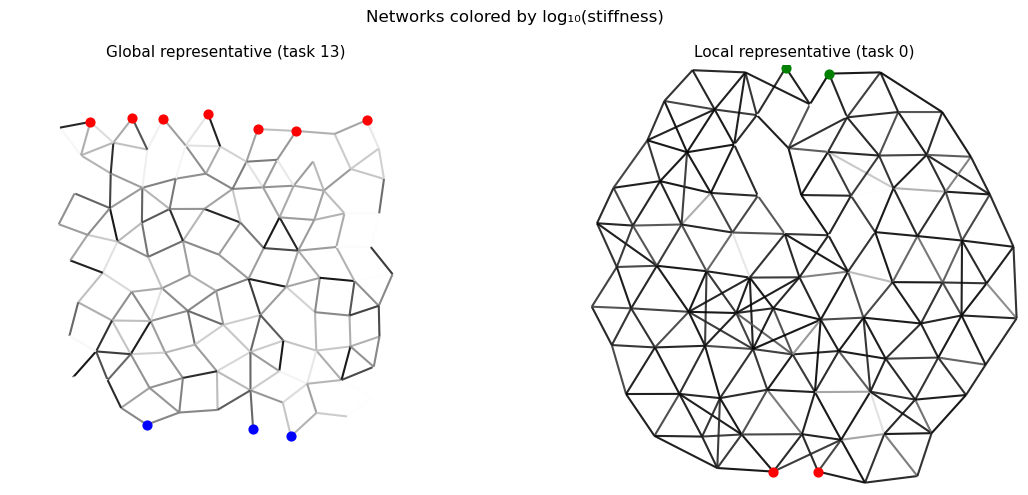

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Global representative
ax = axes[0]
pos_g = np.array(g_rep['positions0'])
edges_g = np.array(g_rep['edges'], dtype=int)
k_g     = np.array(g_rep['stiffnesses'])
lc = draw_network(ax, pos_g, edges_g, k_g, cmap='Greys',
                  highlight_nodes=[g_rep['top'], g_rep['bottom']],
                  highlight_colors=['red', 'blue'])
ax.set_title(f'Global representative (task {GLOBAL_TASK_ID})', fontsize=11)
ax.axis('off')

# Local representative
ax = axes[1]
pos_l   = np.array(l_rep['nodes'])
edges_l = np.array(l_rep['edges'], dtype=int)
k_l     = np.array(l_rep['stiffnesses'])
lc = draw_network(ax, pos_l, edges_l, k_l, cmap='Greys',
                  highlight_nodes=[[0, 1], [2, 3]],
                  highlight_colors=['red', 'green'])
ax.set_title(f'Local representative (task {LOCAL_TASK_ID})', fontsize=11)
ax.axis('off')

plt.suptitle('Networks colored by log₁₀(stiffness)', fontsize=12)
plt.tight_layout()
plt.savefig(FIGURE_OUT_DIR / 'fig1_networks.pdf', bbox_inches='tight', dpi=150)
plt.show()


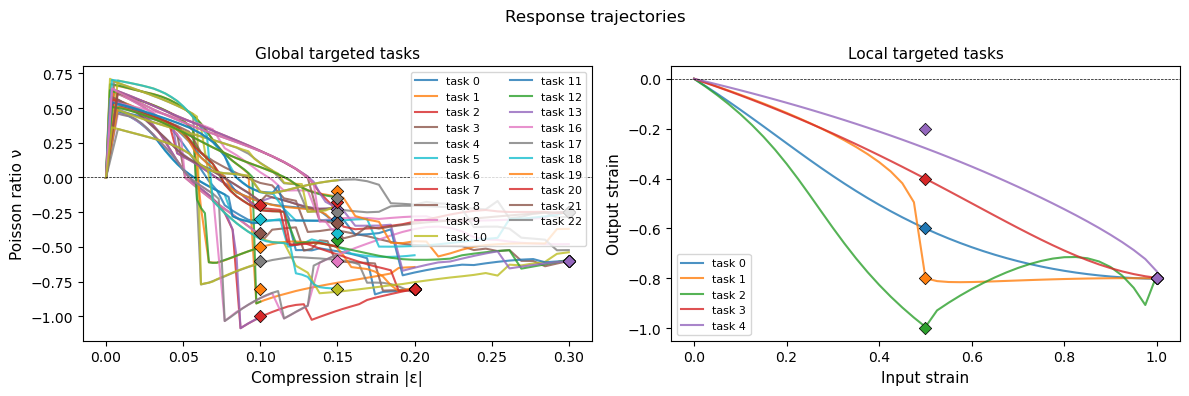

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── Global: Poisson ratio vs compression strain ───────────────────────────────
ax = axes[0]
for task_id in GLOBAL_RESPONSE_TASKS:
    for real_id in [0]:
        try:
            net_resp, bnd_resp, cfg_resp = load_global_network(task_id, real_id, data_dir=TARGETED_DIR)
        except Exception:
            continue
        comp_strains_resp = cfg_resp['compression_strains']
        target_pois_resp  = cfg_resp['target_poisson_ratios']
        task_color = None
        for si, (cs, tp) in enumerate(zip(comp_strains_resp, target_pois_resp)):
            traj_resp = compute_global_traj(net_resp, cs, bnd_resp, n_steps=40)
            strains, nus = poisson_ratio_along_traj(traj_resp, bnd_resp)
            label = f'task {task_id}' if si == 0 else None
            line, = ax.plot(np.abs(strains), nus, alpha=0.8, label=label)
            if task_color is None:
                task_color = line.get_color()
            # Diamond marker at the subtask training target
            ax.scatter([np.abs(cs)], [tp], marker='D', s=40, color=task_color,
                       zorder=5, linewidths=0.5, edgecolors='k')
ax.set_xlabel('Compression strain |ε|', fontsize=11)
ax.set_ylabel('Poisson ratio ν', fontsize=11)
ax.set_title('Global targeted tasks', fontsize=11)
ax.legend(fontsize=8, ncol=2)
ax.axhline(0, c='k', lw=0.5, ls='--')

# ── Local: output strain vs input fraction ────────────────────────────────────
ax = axes[1]
for task_id in range(5):
    try:
        net_resp_l = load_local_targeted(task_id, 0)
    except Exception:
        continue
    if net_resp_l is None:
        continue
    traj_resp_l = compute_local_traj(net_resp_l, n_steps=40)
    inp_frac, out_s = output_strain_along_traj(traj_resp_l, net_resp_l['edges'], net_resp_l['eq_lengths'])
    line, = ax.plot(inp_frac * LOCAL_MAX_STRAIN, out_s, alpha=0.8, label=f'task {task_id}')
    # Diamond markers at the two subtask training targets.
    # target_output* are stored as abs values; output_strain is negative for compression → negate.
    ax.scatter(
        [net_resp_l['strain_input2'], net_resp_l['strain_input']],
        [-net_resp_l['target_output2'], -net_resp_l['target_output']],
        marker='D', s=40, color=line.get_color(),
        zorder=5, linewidths=0.5, edgecolors='k',
    )
ax.set_xlabel('Input strain', fontsize=11)
ax.set_ylabel('Output strain', fontsize=11)
ax.set_title('Local targeted tasks', fontsize=11)
ax.legend(fontsize=8)
ax.axhline(0, c='k', lw=0.5, ls='--')

plt.suptitle('Response trajectories', fontsize=12)
plt.tight_layout()
plt.savefig(FIGURE_OUT_DIR / 'fig1_response_curves.pdf', bbox_inches='tight', dpi=150)
plt.show()


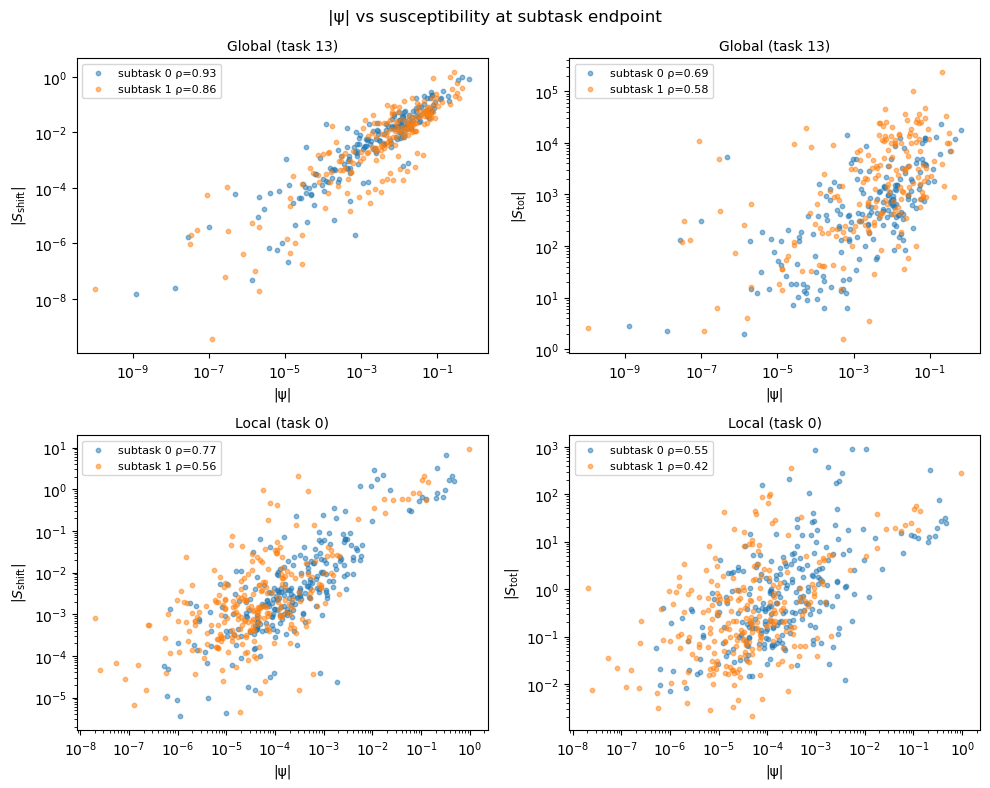

In [ ]:
# For each representative, scatter |ψ| vs |s_shift| and |ψ| vs |s_tot|
# at the endpoint of each subtask.
colors_sub = ['C0', 'C1', 'C2']

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle('|ψ| vs susceptibility at subtask endpoint', fontsize=12)

# ── Global representative ─────────────────────────────────────────────────────
for si in range(N_sub_g):
    psi_g   = np.array(g_rep[f'si{si}_psi'])
    s_shift = np.abs(g_rep[f'si{si}_s_shift'][-1])   # last frame = endpoint
    s_tot   = np.abs(g_rep[f'si{si}_s_tot'][-1])

    rho_sh = spearman_rho(psi_g, s_shift)
    rho_tot = spearman_rho(psi_g, s_tot)

    for ax_idx, (y, rho, ylbl) in enumerate([
        (s_shift, rho_sh, r'$|S_\mathrm{shift}|$'),
        (s_tot,   rho_tot, r'$|S_\mathrm{tot}|$'),
    ]):
        ax = axes[0, ax_idx]
        ax.scatter(psi_g, y, s=10, alpha=0.5, c=colors_sub[si % 3],
                   label=f'subtask {si} ρ={rho:.2f}')
        ax.set_xscale('log'); ax.set_yscale('log')
        ax.set_xlabel(r'|ψ|', fontsize=10)
        ax.set_ylabel(ylbl, fontsize=10)
        ax.set_title(f'Global (task {GLOBAL_TASK_ID})', fontsize=10)
        ax.legend(fontsize=8)

# ── Local representative ──────────────────────────────────────────────────────
for si in range(N_sub_l):
    psi_l     = np.array(l_rep[f'si{si}_psi'])
    s_shift_l = np.abs(l_rep[f'si{si}_s_shift_traj'][-1])
    s_tot_l   = np.abs(l_rep[f'si{si}_s_tot_traj'][-1])
    rho_sh_l  = spearman_rho(psi_l, s_shift_l)
    rho_tot_l = spearman_rho(psi_l, s_tot_l)

    for ax_idx, (y, rho, ylbl) in enumerate([
        (s_shift_l, rho_sh_l, r'$|S_\mathrm{shift}|$'),
        (s_tot_l,   rho_tot_l, r'$|S_\mathrm{tot}|$'),
    ]):
        ax = axes[1, ax_idx]
        ax.scatter(psi_l, y, s=10, alpha=0.5, c=colors_sub[si % 3],
                   label=f'subtask {si} ρ={rho:.2f}')
        ax.set_xscale('log'); ax.set_yscale('log')
        ax.set_xlabel(r'|ψ|', fontsize=10)
        ax.set_ylabel(ylbl, fontsize=10)
        ax.set_title(f'Local (task {LOCAL_TASK_ID})', fontsize=10)
        ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGURE_OUT_DIR / 'fig1_scatter_psi_vs_susc.pdf', bbox_inches='tight', dpi=150)
plt.show()


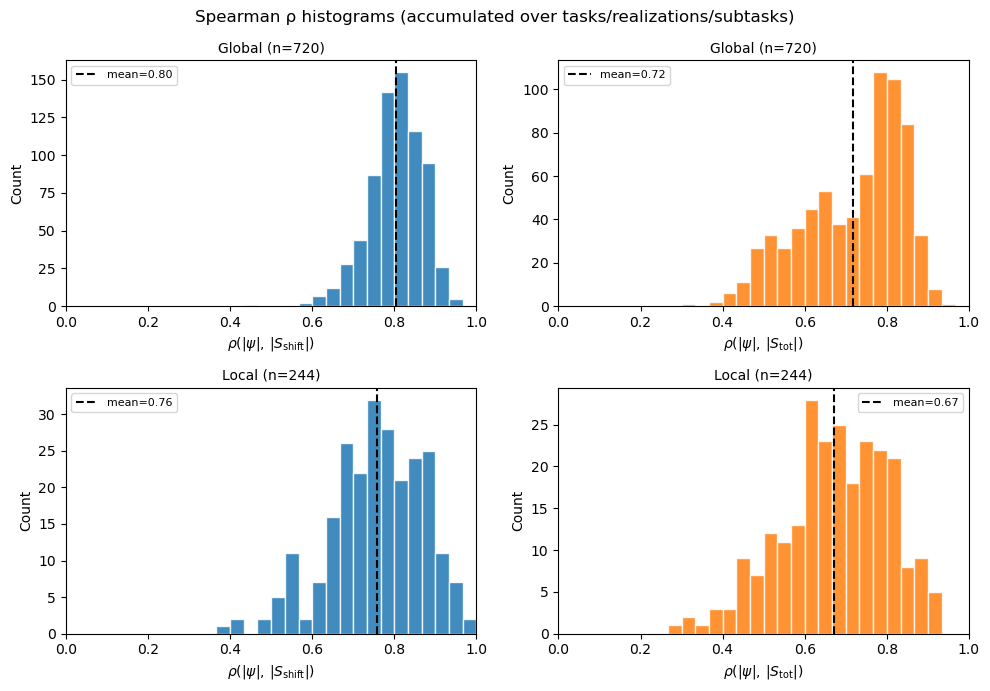

In [ ]:
# Compute Spearman ρ(|ψ|, |s_shift|) and ρ(|ψ|, |s_tot|) for each record
def collect_rhos(records, s_key='s_shift'):
    rhos = []
    for rec in records:
        psi   = np.abs(rec['psi'])
        susc  = np.abs(rec[s_key])
        if len(psi) < 3 or len(susc) < 3:
            continue
        r, _ = spearmanr(psi, susc)
        rhos.append(float(r))
    return np.array(rhos)

global_rho_shift = collect_rhos(global_nt_records, 's_shift')
global_rho_tot   = collect_rhos(global_nt_records, 's_tot')
local_rho_shift  = collect_rhos(local_nt_records,  's_shift')
local_rho_tot    = collect_rhos(local_nt_records,  's_tot')

bins = np.linspace(0, 1, 31)
panel_data = [
    (global_rho_shift, 'Global', r'$\rho(|\psi|,\, |S_\mathrm{shift}|)$', 'C0'),
    (global_rho_tot,   'Global', r'$\rho(|\psi|,\, |S_\mathrm{tot}|)$',   'C1'),
    (local_rho_shift,  'Local',  r'$\rho(|\psi|,\, |S_\mathrm{shift}|)$', 'C0'),
    (local_rho_tot,    'Local',  r'$\rho(|\psi|,\, |S_\mathrm{tot}|)$',   'C1'),
]

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
fig.suptitle('Spearman ρ histograms (accumulated over tasks/realizations/subtasks)', fontsize=12)

for ax, (rhos, kind, xlabel, color) in zip(axes.flatten(), panel_data):
    ax.hist(rhos, bins=bins, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(np.mean(rhos), c='k', ls='--', lw=1.5, label=f'mean={np.mean(rhos):.2f}')
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.set_title(f'{kind} (n={len(rhos)})', fontsize=10)
    ax.legend(fontsize=8)
    ax.set_xlim(0, 1)

plt.tight_layout()
plt.savefig(FIGURE_OUT_DIR / 'fig1_spearman_histograms.pdf', bbox_inches='tight', dpi=150)
plt.show()


## Figure 2 — Mode Dynamics


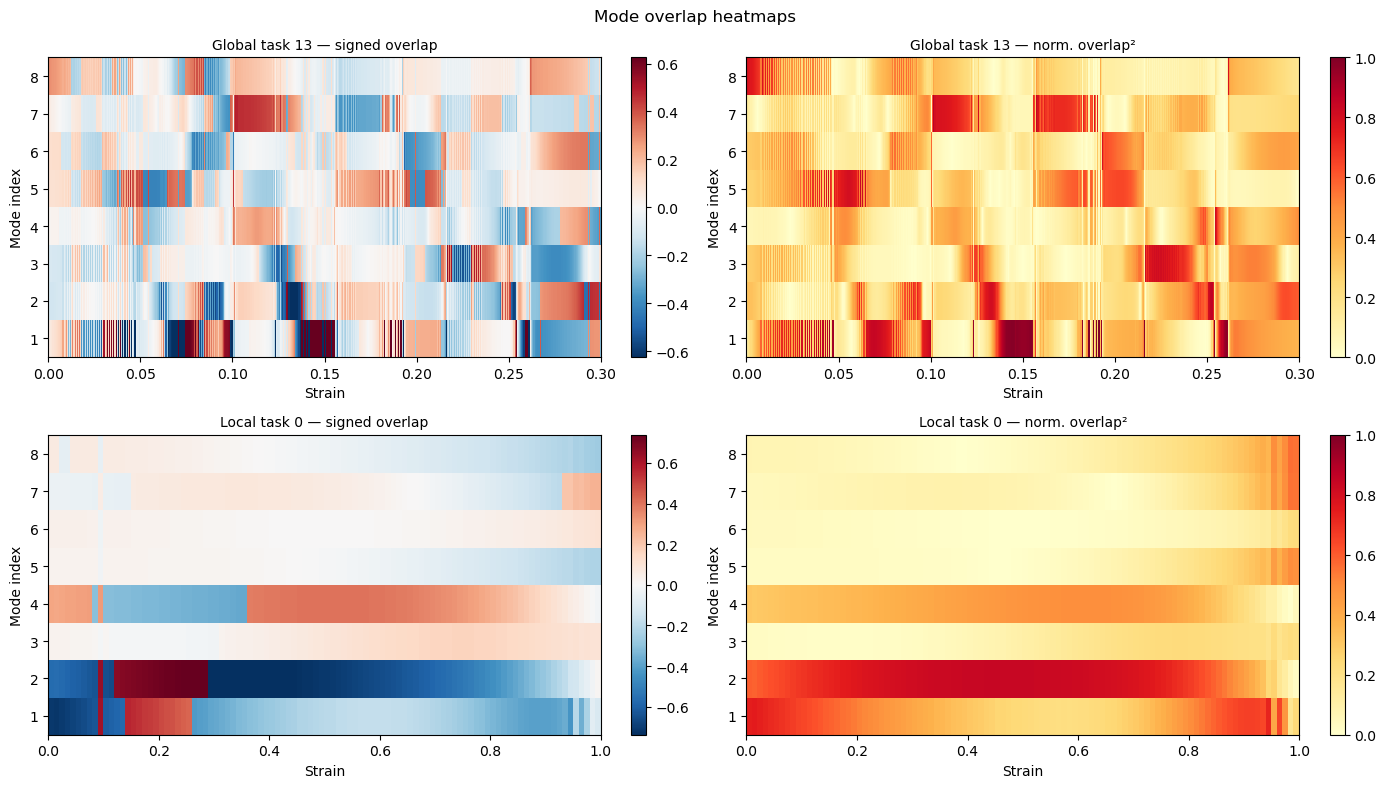

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Mode overlap heatmaps', fontsize=12)

def plot_overlap_heatmap(ax_raw, ax_cos, overlaps, title, strain_axis=None):
    T = overlaps.shape[0]
    M = overlaps.shape[1]
    n_show = min(N_MODES_DISPLAY, M)
    mat = overlaps[:, :n_show].T  # (n_show, T)

    x = strain_axis if strain_axis is not None else np.arange(T)
    extent = [x[0], x[-1], 0.5, n_show + 0.5]

    vmax = float(np.nanpercentile(np.abs(mat), 98)) or 1.0
    im = ax_raw.imshow(mat, aspect='auto', origin='lower', extent=extent,
                       cmap='RdBu_r', vmin=-vmax, vmax=vmax, interpolation='None')
    plt.colorbar(im, ax=ax_raw, fraction=0.04)
    ax_raw.set_xlabel('Strain', fontsize=10)
    ax_raw.set_ylabel('Mode index', fontsize=10)
    ax_raw.set_title(f'{title} — signed overlap', fontsize=10)

    # Cosine (normalised by |dr| already done in compute_analysis)
    o2 = np.abs(overlaps[:, :n_show])
    o2_norm = o2 / (np.linalg.norm(o2, axis=1)[:, np.newaxis] + 1e-12)  # normalise each row
    im2 = ax_cos.imshow(o2_norm.T, aspect='auto', origin='lower', extent=extent,
                        cmap='YlOrRd', vmin=0, vmax=1, interpolation='None')
    plt.colorbar(im2, ax=ax_cos, fraction=0.04)
    ax_cos.set_xlabel('Strain', fontsize=10)
    ax_cos.set_ylabel('Mode index', fontsize=10)
    ax_cos.set_title(f'{title} — norm. overlap²', fontsize=10)

# Global representative (subtask 0)
ov_g   = g_rep['si0_overlaps']
T_g    = ov_g.shape[0]
cs_g   = float(g_rep['comp_strains'][0])
strain_g = np.linspace(0, np.abs(cs_g), T_g)
plot_overlap_heatmap(axes[0, 0], axes[0, 1], ov_g, f'Global task {GLOBAL_TASK_ID}', strain_g)

# Local representative
ov_l   = l_rep['si0_overlaps']
T_l    = ov_l.shape[0]
strain_l = np.linspace(0, LOCAL_MAX_STRAIN, T_l)
plot_overlap_heatmap(axes[1, 0], axes[1, 1], ov_l, f'Local task {LOCAL_TASK_ID}', strain_l)

plt.tight_layout()
plt.savefig(FIGURE_OUT_DIR / 'fig2_overlap_heatmaps.pdf', bbox_inches='tight', dpi=150)
plt.show()


In [ ]:
# Global representative GIF (subtask 0)
traj_g0 = [g_rep['si0_traj'][t] for t in range(len(g_rep['si0_traj']))]
make_actuation_gif(
    traj_g0, g_rep['si0_spectrum'], g_rep['si0_overlaps'],
    g_rep['positions0'], g_rep['edges'], g_rep['stiffnesses'],
    np.array(g_rep['fdofs'], dtype=int),
    FIGURE_OUT_DIR / 'fig2_global_actuation.gif', fps=10)

# Local representative GIF
traj_l_list = [l_rep['si0_traj'][t] for t in range(len(l_rep['si0_traj']))]
make_actuation_gif(
    traj_l_list, l_rep['si0_spectrum'], l_rep['si0_overlaps'],
    {}, l_rep['edges'], l_rep['stiffnesses'],
    np.array(l_rep['fdofs'], dtype=int),
    FIGURE_OUT_DIR / 'fig2_local_actuation.gif', fps=10)


GIF saved → /Users/fmartins/Library/CloudStorage/Box-Box/PhD/nonlinear_mech_nets/figure_data/allfigs/fig2_global_actuation.gif
GIF saved → /Users/fmartins/Library/CloudStorage/Box-Box/PhD/nonlinear_mech_nets/figure_data/allfigs/fig2_local_actuation.gif


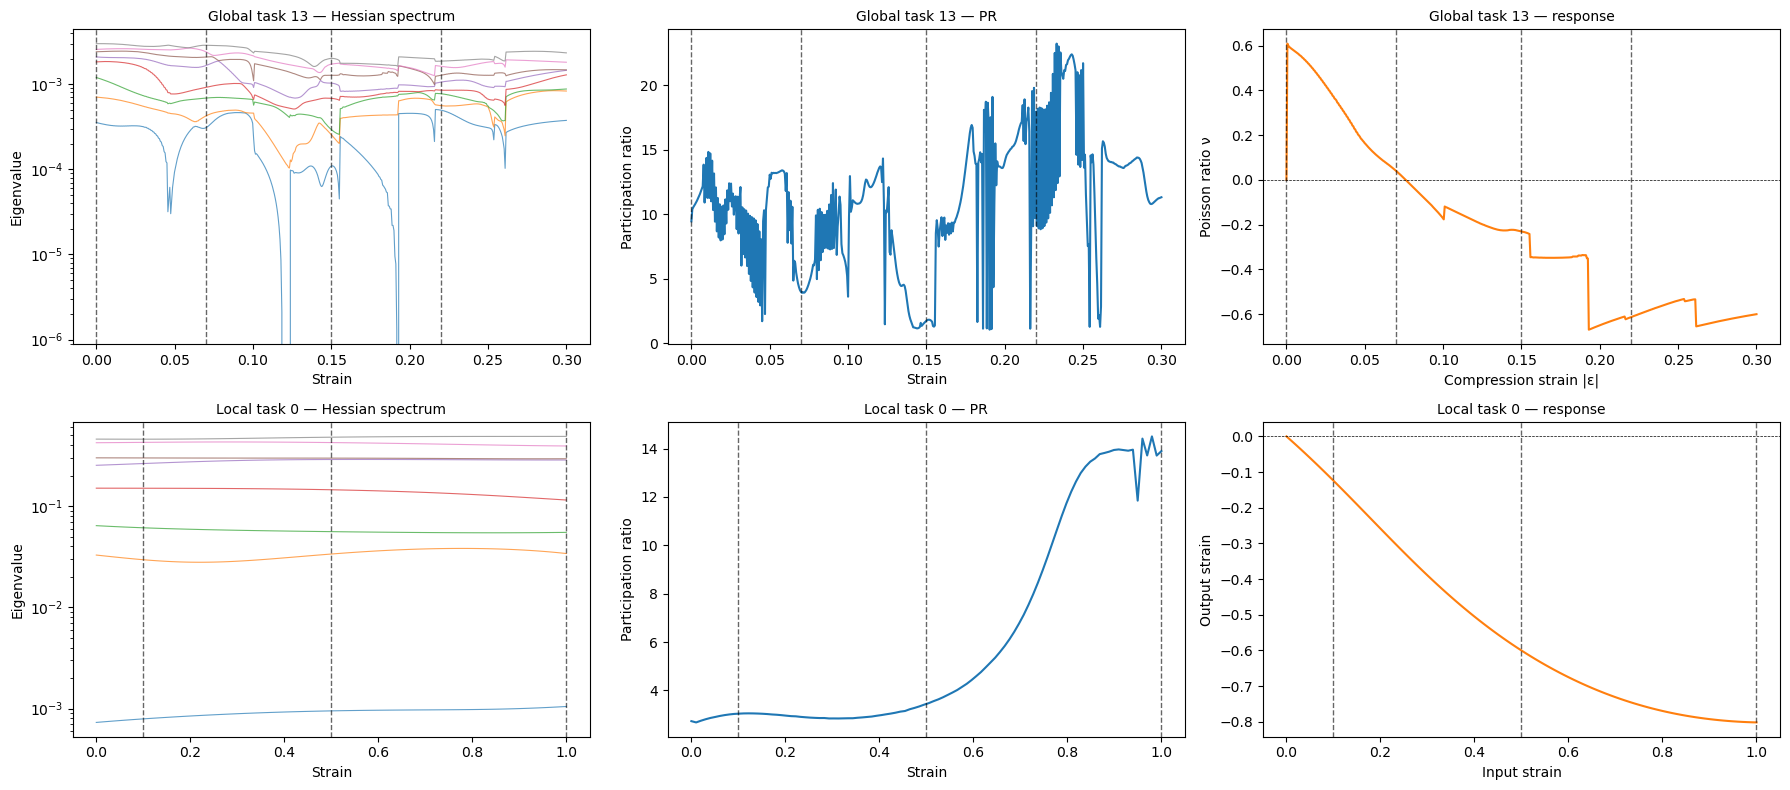

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8))

# ── Pre-compute response data for rightmost column ─────────────────────────────
# Global: reload boundary to compute Poisson ratio from the cached trajectory.
_, _bnd_c27, _ = load_global_network(GLOBAL_TASK_ID, GLOBAL_REAL_ID, data_dir=TARGETED_DIR)
_traj_c27_g = [g_rep["si0_traj"][t] for t in range(len(g_rep["si0_traj"]))]
_strains_c27, _nus_c27 = poisson_ratio_along_traj(_traj_c27_g, _bnd_c27)

# Local: output strain from cached trajectory (eq_lengths stored in l_rep).
_traj_c27_l = [l_rep["si0_traj"][t] for t in range(len(l_rep["si0_traj"]))]
_inp_c27, _out_c27 = output_strain_along_traj(
    _traj_c27_l, np.array(l_rep["edges"], dtype=int), np.array(l_rep["eq_lengths"]))

for row, (label, spectrum, overlaps, max_strain, vlines) in enumerate([
    (f'Global task {GLOBAL_TASK_ID}', g_rep['si0_spectrum'], g_rep['si0_overlaps'],
     np.abs(float(g_rep['comp_strains'][0])), GLOBAL_STRAINS_TO_PLOT),
    (f'Local task {LOCAL_TASK_ID}',   l_rep['si0_spectrum'], l_rep['si0_overlaps'],
     LOCAL_MAX_STRAIN, LOCAL_STRAINS_TO_PLOT),
]):
    T = spectrum.shape[0]
    n_show = min(N_MODES_DISPLAY, spectrum.shape[1])
    strain_ax = np.linspace(0, max_strain, T)

    # Hessian spectrum
    ax = axes[row, 0]
    for m in range(n_show):
        ax.plot(strain_ax, spectrum[:, m], lw=0.8, alpha=0.7)
    for vs in vlines:
        ax.axvline(vs, c='k', lw=1.0, ls='--', alpha=0.6)
    ax.set_xlabel('Strain', fontsize=10)
    ax.set_ylabel('Eigenvalue', fontsize=10)
    ax.set_title(f'{label} — Hessian spectrum', fontsize=10)
    ax.set_yscale('log')

    # Participation ratio
    ax = axes[row, 1]
    pr = participation_ratio(overlaps)
    strain_ax_pr = np.linspace(0, max_strain, len(pr))
    ax.plot(strain_ax_pr, pr, lw=1.5, c='C0')
    for vs in vlines:
        ax.axvline(vs, c='k', lw=1.0, ls='--', alpha=0.6)
    ax.set_xlabel('Strain', fontsize=10)
    ax.set_ylabel('Participation ratio', fontsize=10)
    ax.set_title(f'{label} — PR', fontsize=10)

# Global response: Poisson ratio vs compression strain
ax = axes[0, 2]
ax.plot(np.abs(_strains_c27), _nus_c27, lw=1.5, c='C1')
for vs in GLOBAL_STRAINS_TO_PLOT:
    ax.axvline(vs, c='k', lw=1.0, ls='--', alpha=0.6)
ax.set_xlabel('Compression strain |ε|', fontsize=10)
ax.set_ylabel('Poisson ratio ν', fontsize=10)
ax.set_title(f'Global task {GLOBAL_TASK_ID} — response', fontsize=10)
ax.axhline(0, c='k', lw=0.5, ls='--')

# Local response: output strain vs input strain
ax = axes[1, 2]
ax.plot(_inp_c27 * LOCAL_MAX_STRAIN, _out_c27, lw=1.5, c='C1')
for vs in LOCAL_STRAINS_TO_PLOT:
    ax.axvline(vs, c='k', lw=1.0, ls='--', alpha=0.6)
ax.set_xlabel('Input strain', fontsize=10)
ax.set_ylabel('Output strain', fontsize=10)
ax.set_title(f'Local task {LOCAL_TASK_ID} — response', fontsize=10)
ax.axhline(0, c='k', lw=0.5, ls='--')

plt.tight_layout()
plt.savefig(FIGURE_OUT_DIR / 'fig2_spectrum_pr.pdf', bbox_inches='tight', dpi=150)
plt.show()


/var/folders/dr/wggf6zrd7ss91kjmbvjh7m240000gn/T/ipykernel_53901/1044873843.py:9: RuntimeWarning: invalid value encountered in divide
  return (np.abs(s_trained) / nt) / (np.abs(s_unit) / nu)
/var/folders/dr/wggf6zrd7ss91kjmbvjh7m240000gn/T/ipykernel_53901/1044873843.py:9: RuntimeWarning: invalid value encountered in divide
  return (np.abs(s_trained) / nt) / (np.abs(s_unit) / nu)
/var/folders/dr/wggf6zrd7ss91kjmbvjh7m240000gn/T/ipykernel_53901/1044873843.py:9: RuntimeWarning: invalid value encountered in divide
  return (np.abs(s_trained) / nt) / (np.abs(s_unit) / nu)


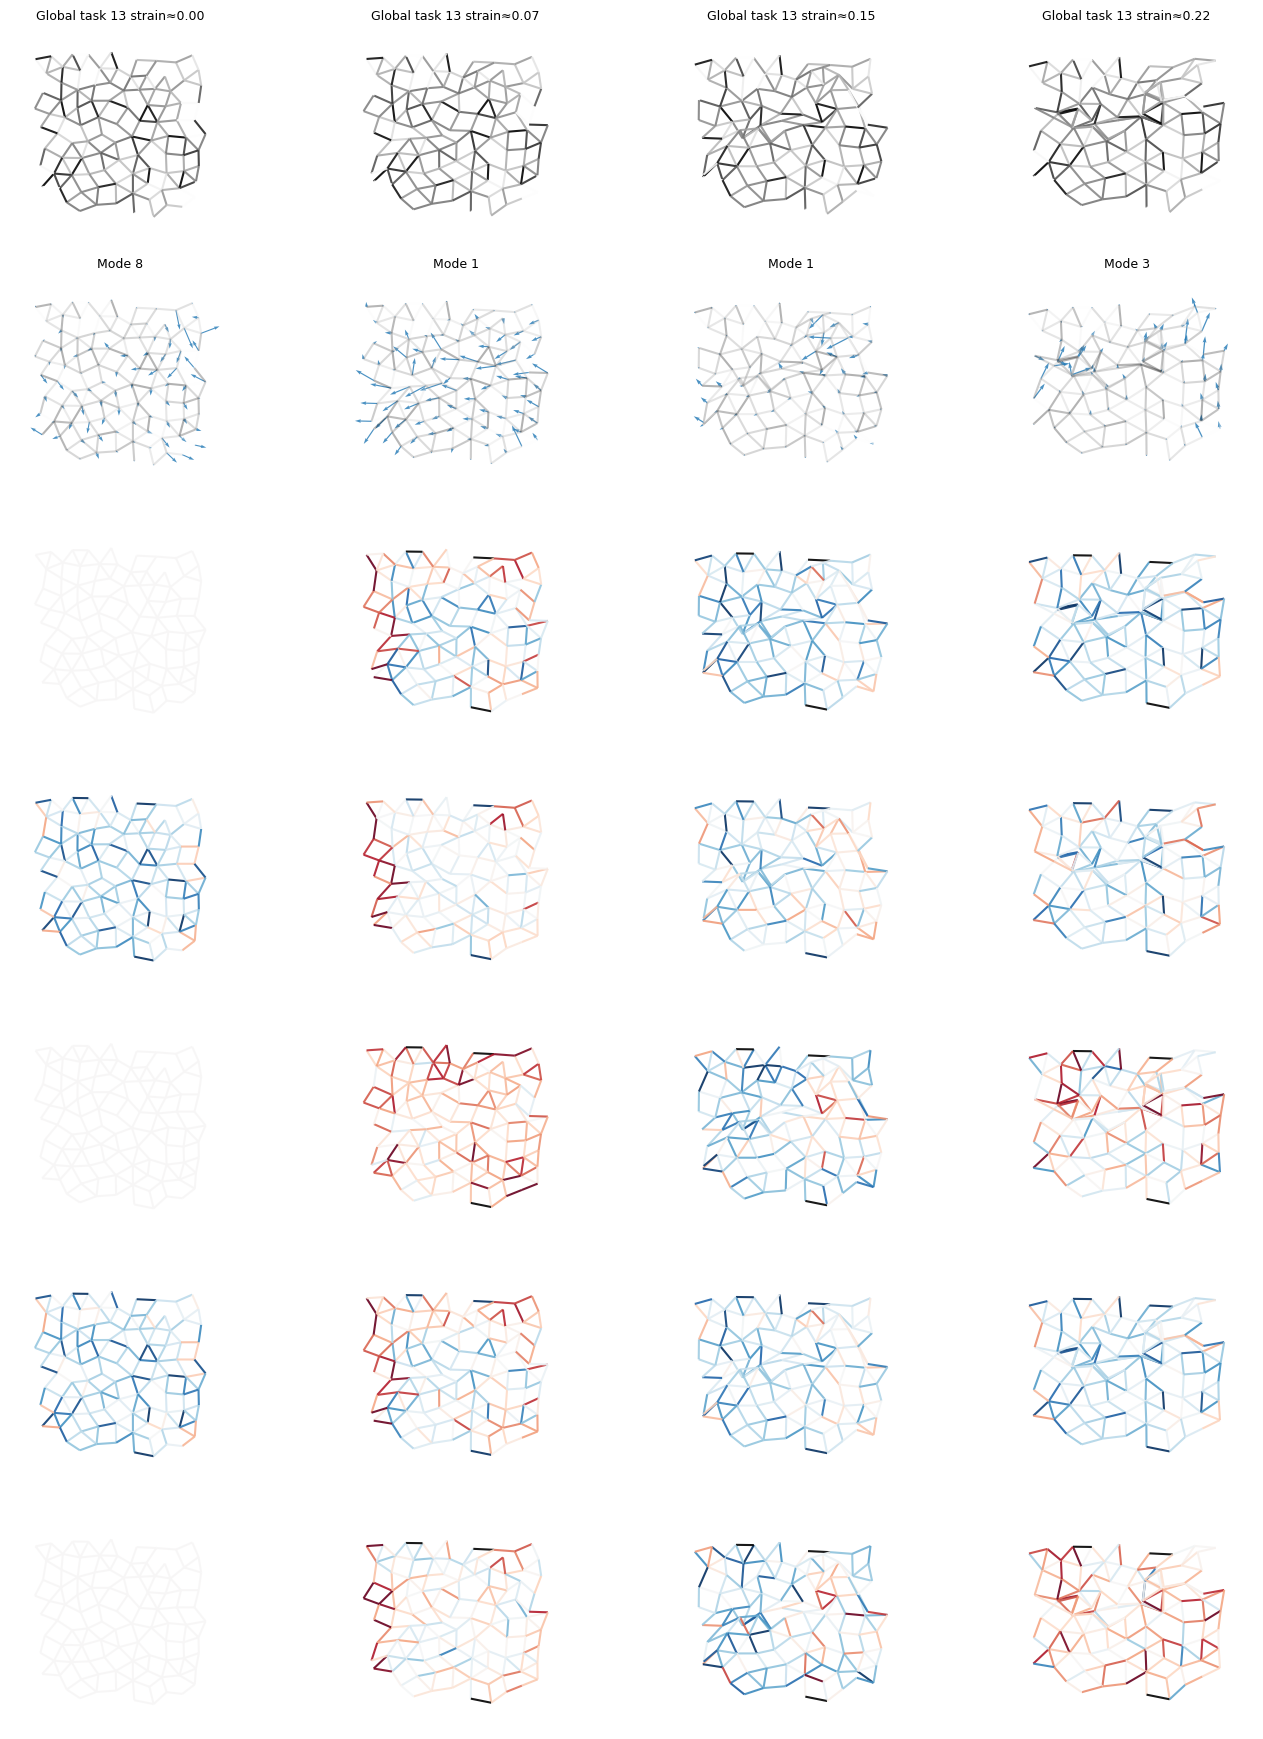

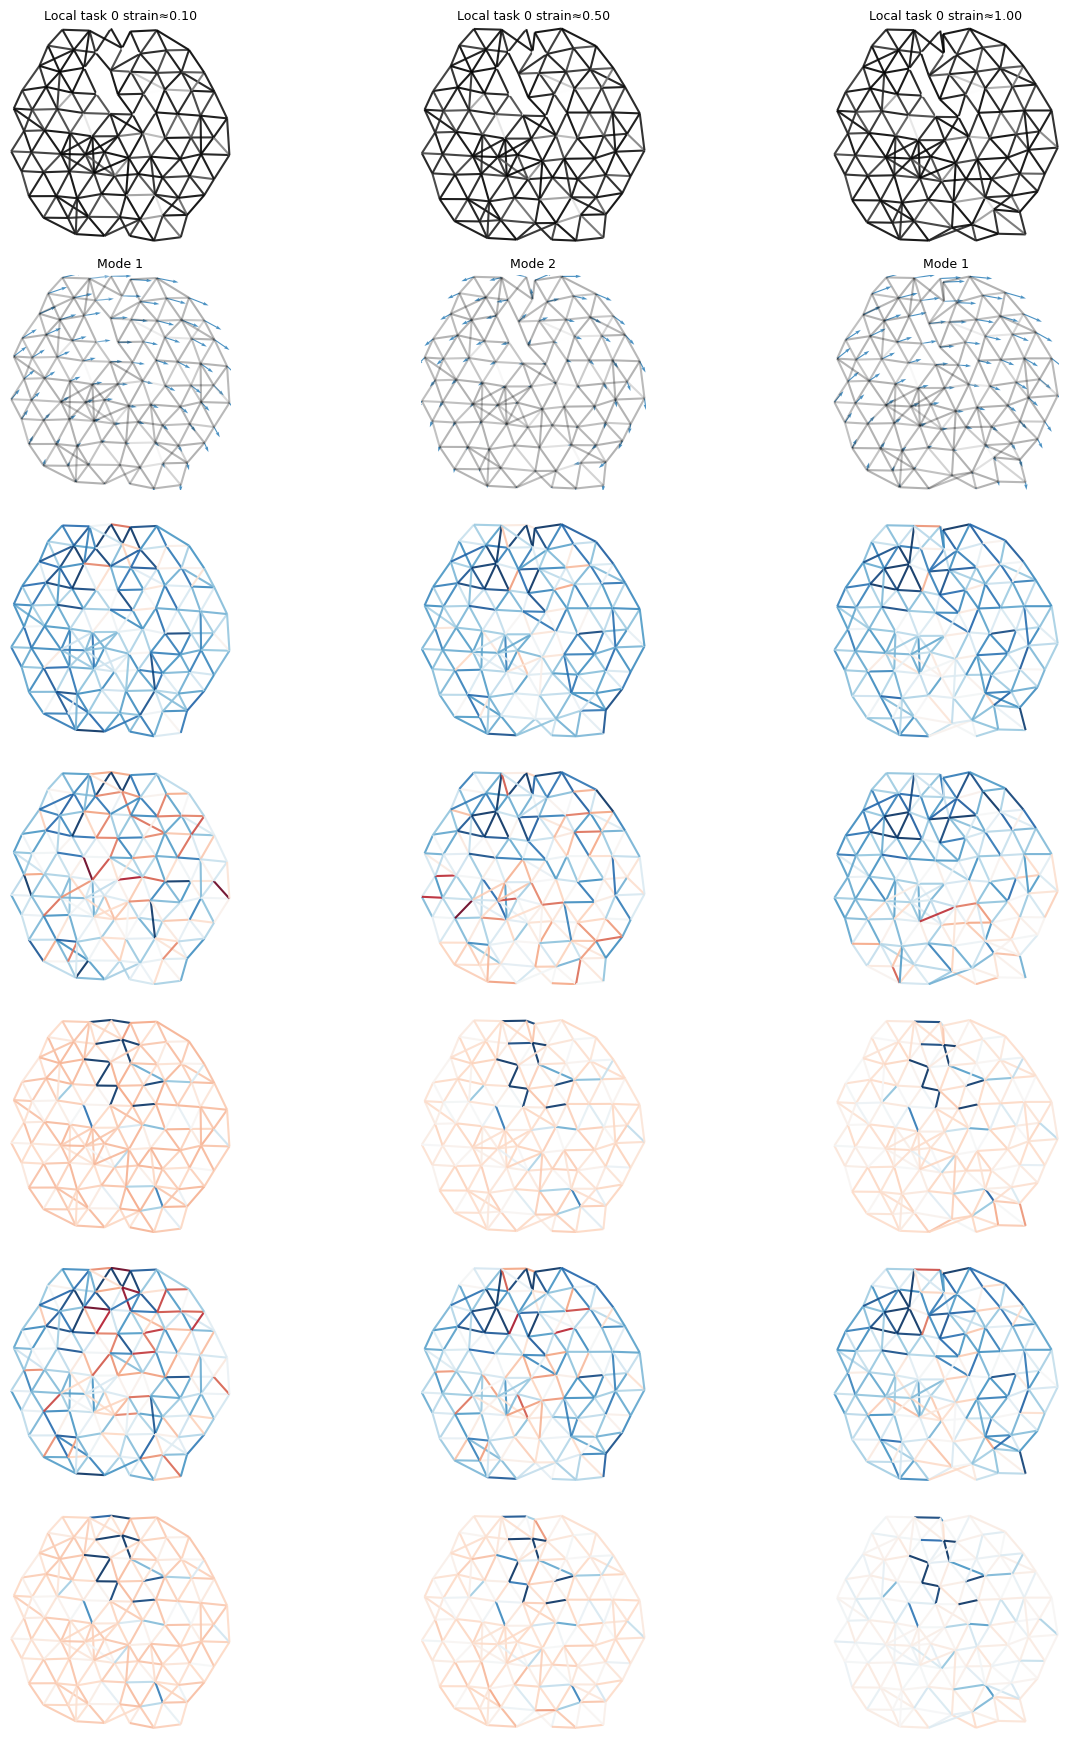

In [ ]:
def _norm_ratio(s_trained, s_unit):
    """Element-wise ratio of L2-normalised susceptibility vectors.
    ratio_e = (|S_e| / ||S||) / (|S_e_unit| / ||S_unit||)
    """
    nt = np.linalg.norm(s_trained)
    nu = np.linalg.norm(s_unit)
    if nt < 1e-20 or nu < 1e-20:
        return np.ones_like(s_trained, dtype=float)
    return (np.abs(s_trained) / nt) / (np.abs(s_unit) / nu)


def plot_network_with_mode(traj, spectrum, overlaps, stiffnesses, edges, eq_lengths, fdofs,
                           constrained_nodes,
                           strains_to_plot, modes_to_plot, strain_vals,
                           title_prefix='', figsize=(14, 2.5)):
    n_snap = len(strains_to_plot)
    n_rows = 7  # stiffness | mode | s_shift | s_tot | s_perp | s_par | s_eq
    _row_labels = ['Stiffness', 'Mode k',
                   r'$|S_{\rm shift}|/|S_{\rm shift}^{(1)}|$',
                   r'$|S_{\rm tot}|/|S_{\rm tot}^{(1)}|$',
                   r'$|S_\perp|/|S_\perp^{(1)}|$',
                   r'$|S_\parallel|/|S_\parallel^{(1)}|$',
                   r'$|S_{\rm eq}|/|S_{\rm eq}^{(1)}|$']
    fig, axes = plt.subplots(n_rows, n_snap, figsize=(figsize[0], figsize[1] * n_rows))

    k_unit = np.ones(len(stiffnesses))

    for col, (strain_target, mode_1idx) in enumerate(zip(strains_to_plot, modes_to_plot)):
        t_idx = find_frame(strain_target, strain_vals)
        pos   = np.array(traj[t_idx])
        vals, vecs_T = hessian_modes(pos, stiffnesses, eq_lengths, edges, fdofs)
        assert np.all(vals >= 0)
        m_idx = mode_1idx - 1

        # Susceptibilities: trained stiffnesses and unit baseline
        s_par,   s_perp,   s_eq,   s_tot   = compute_susceptibilities(
            pos, edges, stiffnesses, eq_lengths, constrained_nodes)
        s_shift = compute_s_shift(pos, edges, stiffnesses, eq_lengths, fdofs)

        s_par_u, s_perp_u, s_eq_u, s_tot_u = compute_susceptibilities(
            pos, edges, k_unit, eq_lengths, constrained_nodes)
        s_shift_u = compute_s_shift(pos, edges, k_unit, eq_lengths, fdofs)

        # Row 0: stiffness
        ax = axes[0, col]
        draw_network(ax, pos, edges, stiffnesses, cmap='Greys')
        ax.set_title(f'{title_prefix} strain≈{strain_vals[t_idx]:.2f}', fontsize=9)
        ax.axis('off')
        if col == 0: ax.set_ylabel(_row_labels[0], fontsize=8)

        # Row 1: mode quiver
        ax = axes[1, col]
        evec_full = np.zeros(2 * pos.shape[0])
        evec_full[fdofs] = vecs_T[m_idx]
        draw_network(ax, pos, edges, stiffnesses, cmap='Greys', alpha=0.3)
        draw_mode_quiver(ax, pos, evec_full, color='C0')
        ax.set_title(f'Mode {mode_1idx}', fontsize=9)
        ax.axis('off')
        if col == 0: ax.set_ylabel(_row_labels[1], fontsize=8)

        # Rows 2-6: normalised susceptibility ratios (log10 scale, diverging)
        for r, (s_tr, s_u) in enumerate([
            (s_shift, s_shift_u),
            (s_tot,   s_tot_u),
            (s_perp,  s_perp_u),
            (s_par,   s_par_u),
            (s_eq,    s_eq_u),
        ]):
            ratio = _norm_ratio(s_tr, s_u)
            log_ratio = np.log10(ratio + 1e-14)
            v = max(np.abs(np.nanpercentile(log_ratio, [2, 98])))
            v = max(v, 1e-3)  # avoid degenerate range
            ax = axes[r + 2, col]
            # Pass ratio; draw_network applies log10 internally → symmetric about 0
            draw_network(ax, pos, edges, ratio, cmap='RdBu_r', vmin=-v, vmax=v)
            ax.axis('off')
            if col == 0: ax.set_ylabel(_row_labels[r + 2], fontsize=8)

    plt.tight_layout()
    return fig


# Global snapshots
strain_vals_g0 = np.linspace(0, np.abs(float(g_rep['comp_strains'][0])),
                              len(g_rep['si0_traj']))
_constrained_g = np.concatenate([
    np.array(g_rep['top'],    dtype=int),
    np.array(g_rep['bottom'], dtype=int),
])
fig = plot_network_with_mode(
    [g_rep['si0_traj'][t] for t in range(len(g_rep['si0_traj']))],
    g_rep['si0_spectrum'], g_rep['si0_overlaps'],
    g_rep['stiffnesses'], g_rep['edges'], g_rep['rest_lengths'], np.array(g_rep['fdofs'], dtype=int),
    _constrained_g,
    GLOBAL_STRAINS_TO_PLOT, GLOBAL_MODES_TO_PLOT, strain_vals_g0,
    title_prefix=f'Global task {GLOBAL_TASK_ID}')
fig.savefig(FIGURE_OUT_DIR / 'fig2_global_snapshots.pdf', bbox_inches='tight', dpi=150)
plt.show()

# Local snapshots
strain_vals_l = np.linspace(0, LOCAL_MAX_STRAIN, len(l_rep['si0_traj']))
fig = plot_network_with_mode(
    [l_rep['si0_traj'][t] for t in range(len(l_rep['si0_traj']))],
    l_rep['si0_spectrum'], l_rep['si0_overlaps'],
    l_rep['stiffnesses'], l_rep['edges'], l_rep['eq_lengths'], np.array(l_rep['fdofs'], dtype=int),
    [0, 1],
    LOCAL_STRAINS_TO_PLOT, LOCAL_MODES_TO_PLOT, strain_vals_l,
    title_prefix=f'Local task {LOCAL_TASK_ID}')
fig.savefig(FIGURE_OUT_DIR / 'fig2_local_snapshots.pdf', bbox_inches='tight', dpi=150)
plt.show()


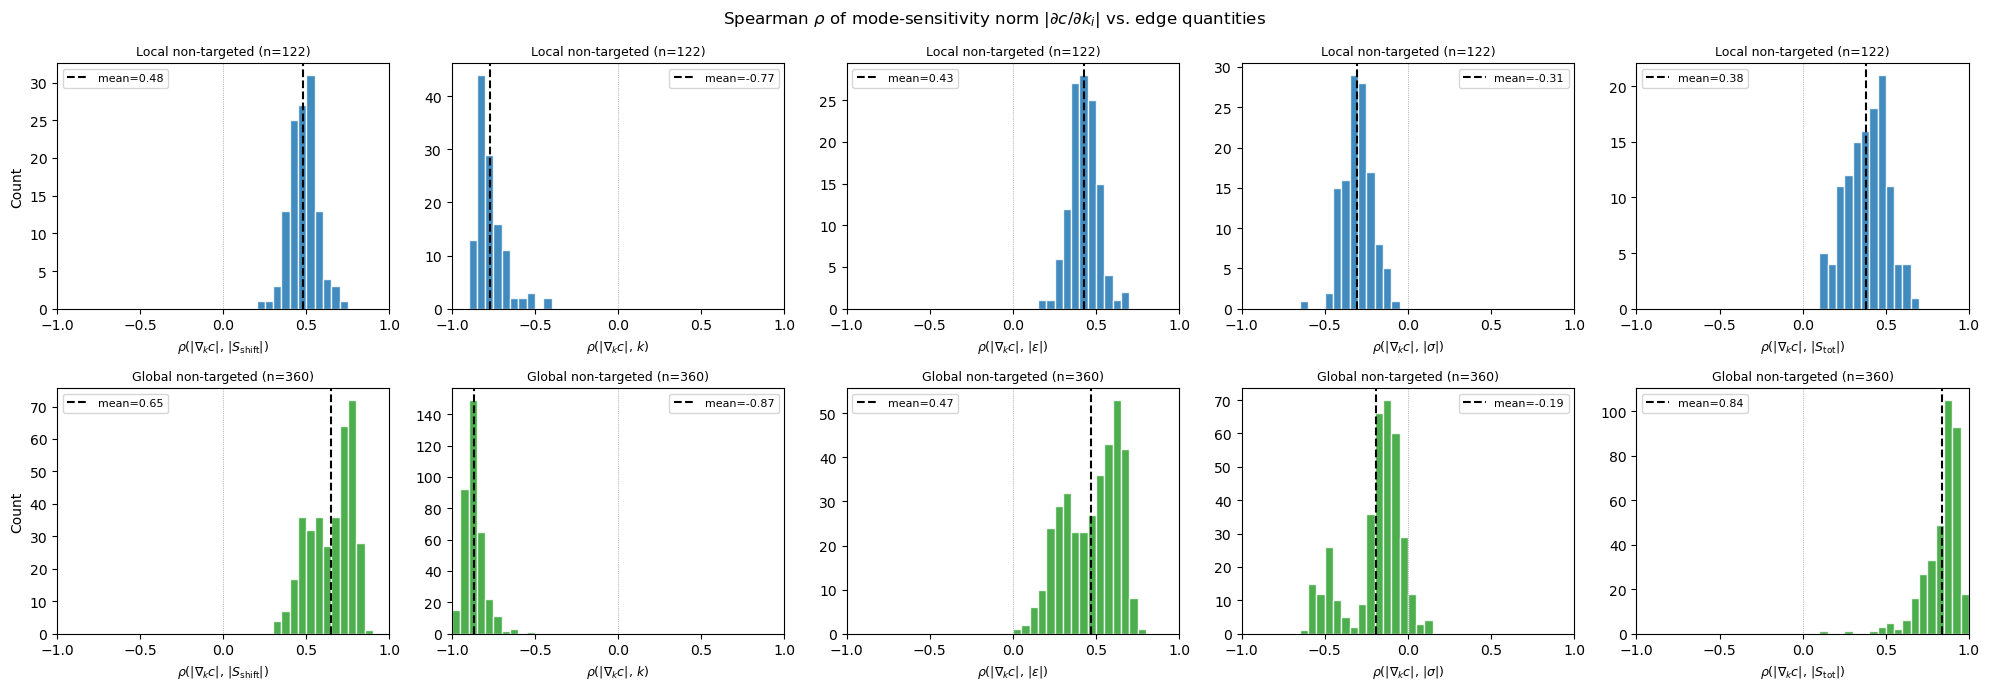

In [ ]:
_rho_specs = [
    ('rho',        r'$\rho(|\nabla_k c|,\, |S_{\rm shift}|)$'),
    ('rho_k',      r'$\rho(|\nabla_k c|,\, k)$'),
    ('rho_strain', r'$\rho(|\nabla_k c|,\, |\varepsilon|)$'),
    ('rho_stress', r'$\rho(|\nabla_k c|,\, |\sigma|)$'),
    ('rho_stot',   r'$\rho(|\nabla_k c|,\, |S_{\rm tot}|)$'),
]

bins = np.linspace(-1, 1, 41)
n_rho = len(_rho_specs)
fig, axes = plt.subplots(2, n_rho, figsize=(4 * n_rho, 7))

for row, (records, label, color) in enumerate([
    (local_h_records,  'Local non-targeted',  'C0'),
    (global_h_records, 'Global non-targeted', 'C2'),
]):
    for col, (rkey, xlabel) in enumerate(_rho_specs):
        ax = axes[row, col]
        rhos_col = np.array([rec[rkey] for rec in records if rkey in rec])
        if len(rhos_col) == 0:
            ax.text(0.5, 0.5, 'no data', ha='center', va='center', transform=ax.transAxes)
            continue
        ax.hist(rhos_col, bins=bins, color=color, edgecolor='white', alpha=0.85)
        ax.axvline(np.mean(rhos_col), c='k', ls='--', lw=1.5,
                   label=f'mean={np.mean(rhos_col):.2f}')
        ax.set_xlabel(xlabel, fontsize=9)
        ax.set_ylabel('Count' if col == 0 else '', fontsize=10)
        ax.set_title(f'{label} (n={len(rhos_col)})', fontsize=9)
        ax.legend(fontsize=8)
        ax.set_xlim(-1, 1)
        ax.axvline(0, c='grey', lw=0.5, ls=':')

plt.suptitle(r'Spearman $\rho$ of mode-sensitivity norm $|\partial c/\partial k_i|$ vs. edge quantities',
             fontsize=12)
plt.tight_layout()
plt.savefig(FIGURE_OUT_DIR / 'fig2_modesens_histogram.pdf', bbox_inches='tight', dpi=150)
plt.show()


## Figure 3 — Ensemble Correlations


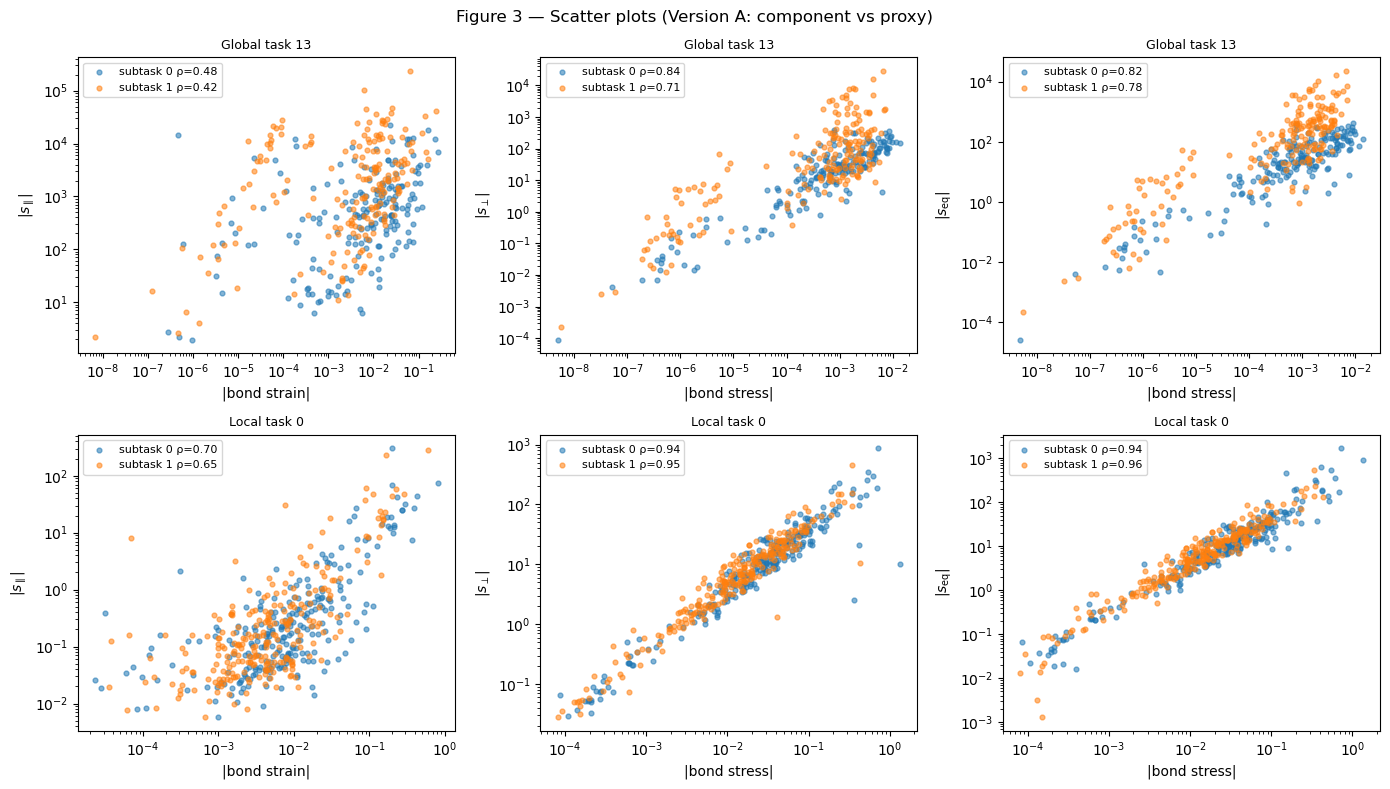

In [ ]:
colors_sub = ['C0', 'C1']

def scatter_pair(ax, x, y, xlabel, ylabel, rho=None, c='C0', label=None):
    ax.scatter(np.abs(x), np.abs(y), s=12, alpha=0.55, c=c,
               label=label or (f'ρ={rho:.2f}' if rho is not None else ''))
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.legend(fontsize=8)

# ── Version A: s_par vs |strain|, s_perp vs |stress|, s_eq vs |stress| ───────
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Figure 3 — Scatter plots (Version A: component vs proxy)', fontsize=12)

for row, (label, is_global) in enumerate([
    (f'Global task {GLOBAL_TASK_ID}', True),
    (f'Local task {LOCAL_TASK_ID}',   False),
]):
    if is_global:
        n_sub = N_sub_g
        get_data = lambda si, key: g_rep[f'si{si}_{key}'][-1]
        get_bond = lambda si: bond_strain_stress(
            g_rep[f'si{si}_traj'][-1], g_rep['edges'],
            g_rep['stiffnesses'], g_rep['rest_lengths'])
    else:
        n_sub = N_sub_l
        get_data = lambda si, key: l_rep[f'si{si}_{key}_traj'][-1]
        get_bond = lambda si: bond_strain_stress(
            l_rep[f'si{si}_traj'][-1], l_rep['edges'],
            l_rep['stiffnesses'], l_rep['eq_lengths'])

    for si in range(n_sub):
        b_strain, b_stress = get_bond(si)
        s_par  = get_data(si, 's_par')
        s_perp = get_data(si, 's_perp')
        s_eq   = get_data(si, 's_eq')
        c      = colors_sub[si % 2]

        for ax, (x, y, xl, yl) in zip(axes[row], [
            (b_strain, s_par,  r'|bond strain|',  r'$|s_\parallel|$'),
            (b_stress, s_perp, r'|bond stress|',  r'$|s_\perp|$'),
            (b_stress, s_eq,   r'|bond stress|',  r'$|s_\mathrm{eq}|$'),
        ]):
            rho = spearman_rho(np.abs(x), np.abs(y))
            scatter_pair(ax, x, y, xl, yl, rho=rho, c=c, label=f'subtask {si} ρ={rho:.2f}')
            ax.set_title(label, fontsize=9)
            ax.set_xscale('log'); ax.set_yscale('log')

plt.tight_layout()
plt.savefig(FIGURE_OUT_DIR / 'fig3_scatter_vA.pdf', bbox_inches='tight', dpi=150)
plt.show()

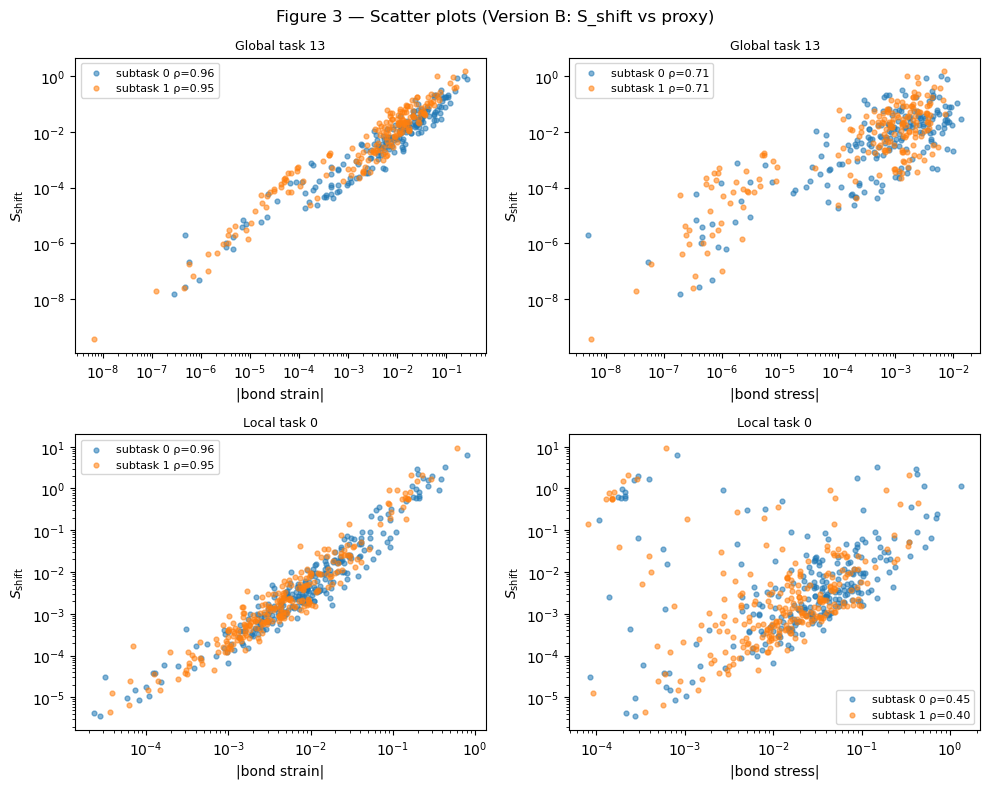

In [ ]:

# ── Version B: s_shift vs |strain|, s_shift vs |stress| ──────────────────────
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle('Figure 3 — Scatter plots (Version B: S_shift vs proxy)', fontsize=12)

for row, (label, is_global) in enumerate([
    (f'Global task {GLOBAL_TASK_ID}', True),
    (f'Local task {LOCAL_TASK_ID}',   False),
]):
    if is_global:
        n_sub = N_sub_g
        get_sshift = lambda si: g_rep[f'si{si}_s_shift'][-1]
        get_bond   = lambda si: bond_strain_stress(
            g_rep[f'si{si}_traj'][-1], g_rep['edges'],
            g_rep['stiffnesses'], g_rep['rest_lengths'])
    else:
        n_sub = N_sub_l
        get_sshift = lambda si: l_rep[f'si{si}_s_shift_traj'][-1]
        get_bond   = lambda si: bond_strain_stress(
            l_rep[f'si{si}_traj'][-1], l_rep['edges'],
            l_rep['stiffnesses'], l_rep['eq_lengths'])

    for si in range(n_sub):
        b_strain, b_stress = get_bond(si)
        s_shift = get_sshift(si)
        c       = colors_sub[si % 2]

        for col, (x, xl) in enumerate([(b_strain, r'|bond strain|'), (b_stress, r'|bond stress|')]):
            ax  = axes[row, col]
            rho = spearman_rho(np.abs(x), np.abs(s_shift))
            scatter_pair(ax, x, s_shift, xl, r'$S_\mathrm{shift}$',
                         rho=rho, c=c, label=f'subtask {si} ρ={rho:.2f}')
            ax.set_title(label, fontsize=9)
            ax.set_xscale('log'); ax.set_yscale('log')

plt.tight_layout()
plt.savefig(FIGURE_OUT_DIR / 'fig3_scatter_vB.pdf', bbox_inches='tight', dpi=150)
plt.show()


/var/folders/dr/wggf6zrd7ss91kjmbvjh7m240000gn/T/ipykernel_53901/285617172.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


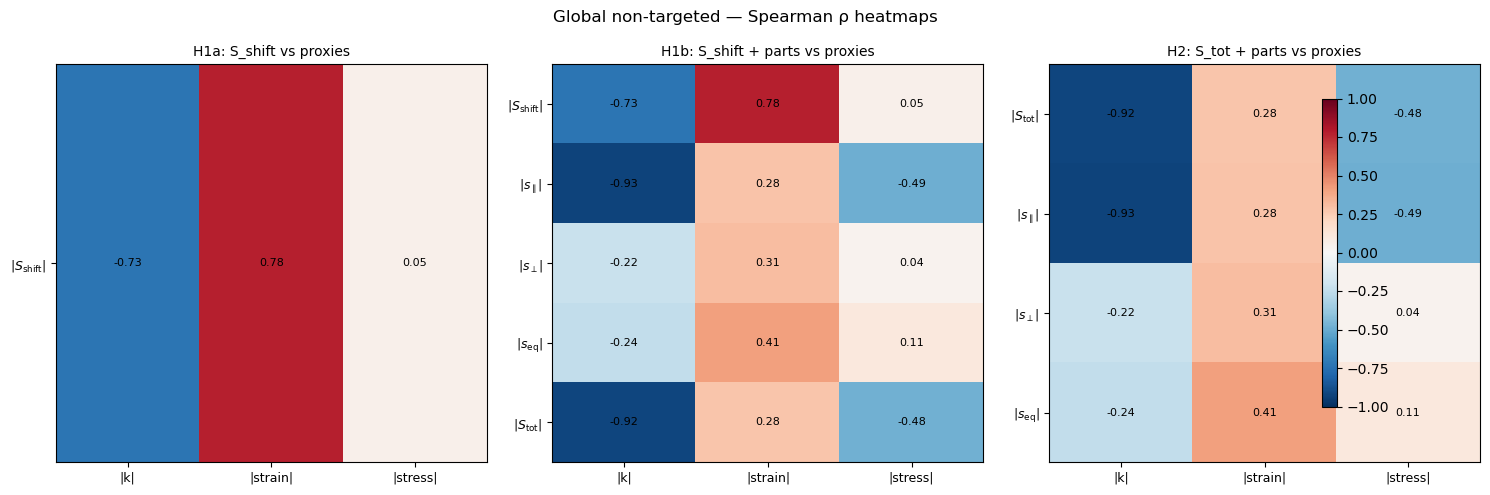

/var/folders/dr/wggf6zrd7ss91kjmbvjh7m240000gn/T/ipykernel_53901/285617172.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


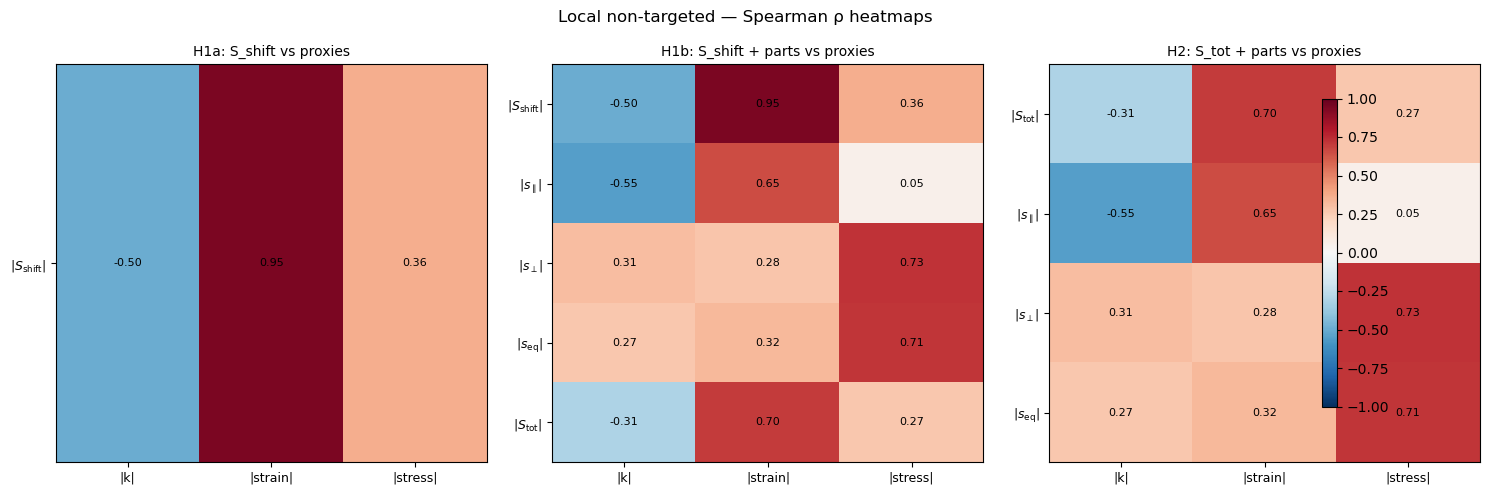

In [ ]:
def grand_spearman_matrix(records, row_keys, col_keys):
    """Compute Spearman ρ matrix by stacking all edges from all records.
    Shape: (len(row_keys), len(col_keys)).
    """
    rows_data = {k: [] for k in row_keys}
    cols_data = {k: [] for k in col_keys}
    for rec in records:
        for k in row_keys:
            rows_data[k].append(np.abs(rec[k]))
        for k in col_keys:
            cols_data[k].append(np.abs(rec[k]))

    rho_mat = np.zeros((len(row_keys), len(col_keys)))
    for ri, rk in enumerate(row_keys):
        x = np.concatenate(rows_data[rk])
        for ci, ck in enumerate(col_keys):
            y = np.concatenate(cols_data[ck])
            rho_mat[ri, ci] = spearman_rho(x, y)
    return rho_mat


def plot_corr_heatmap(ax, mat, row_labels, col_labels, title):
    im = ax.imshow(mat, vmin=-1, vmax=1, cmap='RdBu_r', aspect='auto')
    ax.set_xticks(range(len(col_labels))); ax.set_xticklabels(col_labels, fontsize=9)
    ax.set_yticks(range(len(row_labels))); ax.set_yticklabels(row_labels, fontsize=9)
    ax.set_title(title, fontsize=10)
    for ri in range(len(row_labels)):
        for ci in range(len(col_labels)):
            ax.text(ci, ri, f'{mat[ri, ci]:.2f}', ha='center', va='center', fontsize=8)
    return im


proxy_keys  = ['stiffnesses', 'bond_strain', 'bond_stress']
proxy_lbls  = ['|k|',         '|strain|',    '|stress|']

# Heatmap 1a: rows = [s_shift], cols = proxies
# Heatmap 1b: rows = [s_shift, s_par, s_perp, s_eq, s_tot], cols = proxies
# Heatmap 2:  rows = [s_tot, s_par, s_perp, s_eq],          cols = proxies

row_keys_1a = ['s_shift']
row_lbls_1a = [r'$|S_\mathrm{shift}|$']
row_keys_1b = ['s_shift', 's_par', 's_perp', 's_eq', 's_tot']
row_lbls_1b = [r'$|S_\mathrm{shift}|$', r'$|s_\parallel|$', r'$|s_\perp|$',
               r'$|s_\mathrm{eq}|$',    r'$|S_\mathrm{tot}|$']
row_keys_2  = ['s_tot', 's_par', 's_perp', 's_eq']
row_lbls_2  = [r'$|S_\mathrm{tot}|$', r'$|s_\parallel|$', r'$|s_\perp|$', r'$|s_\mathrm{eq}|$']

for kind, records in [('Global non-targeted', global_nt_records),
                       ('Local non-targeted',  local_nt_records)]:
    if not records:
        print(f'No records for {kind}'); continue

    mat1a = grand_spearman_matrix(records, row_keys_1a, proxy_keys)
    mat1b = grand_spearman_matrix(records, row_keys_1b, proxy_keys)
    mat2  = grand_spearman_matrix(records, row_keys_2,  proxy_keys)

    fig, axes = plt.subplots(1, 3, figsize=(15, max(3, len(row_keys_1b))))
    fig.suptitle(f'{kind} — Spearman ρ heatmaps', fontsize=12)

    im = plot_corr_heatmap(axes[0], mat1a, row_lbls_1a, proxy_lbls, 'H1a: S_shift vs proxies')
    plot_corr_heatmap(axes[1], mat1b, row_lbls_1b, proxy_lbls, 'H1b: S_shift + parts vs proxies')
    plot_corr_heatmap(axes[2], mat2,  row_lbls_2,  proxy_lbls, 'H2: S_tot + parts vs proxies')
    plt.colorbar(im, ax=axes, fraction=0.02, shrink=0.8)
    plt.tight_layout()
    fname = 'global' if 'Global' in kind else 'local'
    plt.savefig(FIGURE_OUT_DIR / f'fig3_heatmaps_{fname}.pdf', bbox_inches='tight', dpi=150)
    plt.show()


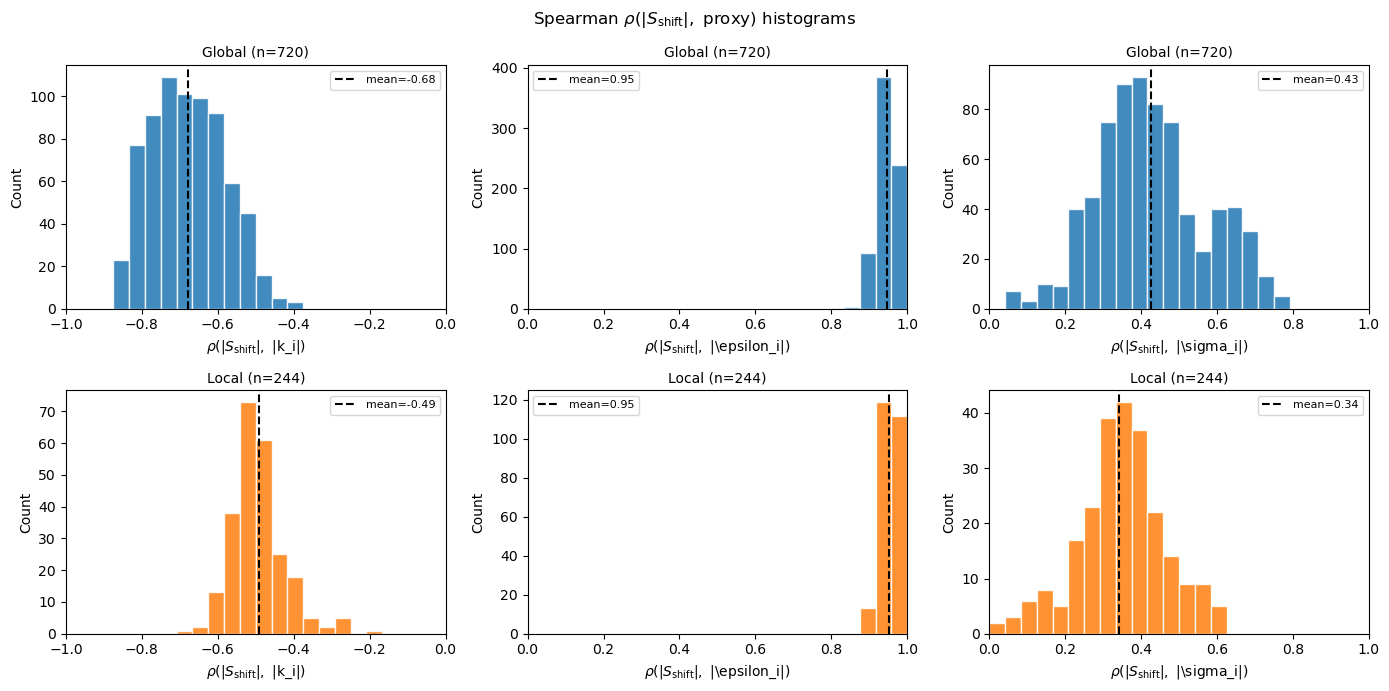

In [ ]:
def collect_per_record_rhos(records, s_key, proxy_key):
    rhos = []
    for rec in records:
        x = np.abs(rec[s_key])
        y = np.abs(rec[proxy_key])
        if len(x) < 3: continue
        rhos.append(spearman_rho(x, y))
    return np.array(rhos)


fig, axes = plt.subplots(2, 3, figsize=(14, 7))
fig.suptitle(r'Spearman $\rho(|S_\mathrm{shift}|,\ \mathrm{proxy})$ histograms', fontsize=12)

for row, (records, kind, color) in enumerate([
    (global_nt_records, 'Global', 'C0'),
    (local_nt_records,  'Local',  'C1'),
]):
    for col, (proxy_key, proxy_lbl) in enumerate([
        ('stiffnesses', r'$|k_i|$'),
        ('bond_strain', r'$|\epsilon_i|$'),
        ('bond_stress', r'$|\sigma_i|$'),
    ]):
        
        if proxy_key != 'stiffnesses':
            bins = np.linspace(0, 1, 25)
        else:
            bins = np.linspace(-1, 0, 25)

        ax   = axes[row, col]
        rhos = collect_per_record_rhos(records, 's_shift', proxy_key)
        ax.hist(rhos, bins=bins, color=color, edgecolor='white', alpha=0.85)
        ax.axvline(np.mean(rhos), c='k', ls='--', lw=1.5, label=f'mean={np.mean(rhos):.2f}')
        ax.set_xlabel(fr'$\rho(|S_\mathrm{{shift}}|,\ {proxy_lbl})$', fontsize=10)
        ax.set_ylabel('Count', fontsize=10)
        ax.set_title(f'{kind} (n={len(rhos)})', fontsize=10)
        ax.legend(fontsize=8)
        if proxy_key!= 'stiffnesses':
            ax.set_xlim(0, 1)
        else:
            ax.set_xlim(-1, 0)

plt.tight_layout()
plt.savefig(FIGURE_OUT_DIR / 'fig3_proxy_rho_histograms.pdf', bbox_inches='tight', dpi=150)
plt.show()


# Debug: Modes 

In [ ]:
# Debug: GIF of global representative — 8 lowest Hessian modes during compression
# Layout: 2 rows × 4 columns; each subpanel = one mode; frames = compression steps

import matplotlib.animation as animation

_traj_g0     = [g_rep["si0_traj"][t] for t in range(len(g_rep["si0_traj"]))]
_stiff_g     = np.array(g_rep["stiffnesses"])
_edges_g     = np.array(g_rep["edges"], dtype=int)
_fdofs_g     = np.array(g_rep["fdofs"], dtype=int)
_pos0_g      = np.array(g_rep["si0_traj"][0])
_N_g         = _pos0_g.shape[0]
_B_g         = build_incidence_matrix(_edges_g, _N_g)
_eq_lens_g   = np.linalg.norm(_B_g @ _pos0_g, axis=1)
_comp_strain = np.abs(float(g_rep["comp_strains"][0]))
_strain_vals = np.linspace(0, _comp_strain, len(_traj_g0))

_N_MODES = 8
_fps     = 8

_fig_d, _axes_d = plt.subplots(2, 4, figsize=(16, 8))
_axes_flat = _axes_d.ravel()

def _update(t):
    pos = np.array(_traj_g0[t])
    vals, vecs_T = hessian_modes(pos, _stiff_g, _eq_lens_g, _edges_g, _fdofs_g)
    for mi in range(_N_MODES):
        ax = _axes_flat[mi]
        ax.clear()
        draw_network(ax, pos, _edges_g, _stiff_g, cmap="Greys", alpha=0.35)
        evec_full = np.zeros(2 * pos.shape[0])
        evec_full[_fdofs_g] = vecs_T[mi]
        draw_mode_quiver(ax, pos, evec_full, color=f"C{mi}", alpha=0.85)
        ax.set_title(f"Mode {mi+1}  λ={vals[mi]:.3g}", fontsize=8)
        ax.axis("off")
    _fig_d.suptitle(f"Global rep (task {GLOBAL_TASK_ID}) — strain {_strain_vals[t]:.3f}",
                    fontsize=11)
    return []

def _init():
    for ax in _axes_flat:
        ax.clear()
    return []

_anim = animation.FuncAnimation(
    _fig_d, _update, init_func=_init,
    frames=len(_traj_g0), interval=1000 // _fps, blit=False
)
_gif_path = FIGURE_OUT_DIR / "debug_global_8modes.gif"
_writer = animation.PillowWriter(fps=_fps)
_anim.save(str(_gif_path), writer=_writer)
plt.close(_fig_d)
print(f"Debug GIF saved → {_gif_path}")


Debug GIF saved → /Users/fmartins/Library/CloudStorage/Box-Box/PhD/nonlinear_mech_nets/figure_data/allfigs/debug_global_8modes.gif


In [ ]:
evals, evec = hessian_modes(_traj_g0[0], _stiff_g, _eq_lens_g, _edges_g, _fdofs_g)

(array([106.,  31.,  12.,   6.,   5.,   4.,   4.,   2.,   2.,   4.]),
 array([3.54994744e-04, 2.38462082e-01, 4.76569170e-01, 7.14676258e-01,
        9.52783346e-01, 1.19089043e+00, 1.42899752e+00, 1.66710461e+00,
        1.90521170e+00, 2.14331878e+00, 2.38142587e+00]),
 <BarContainer object of 10 artists>)

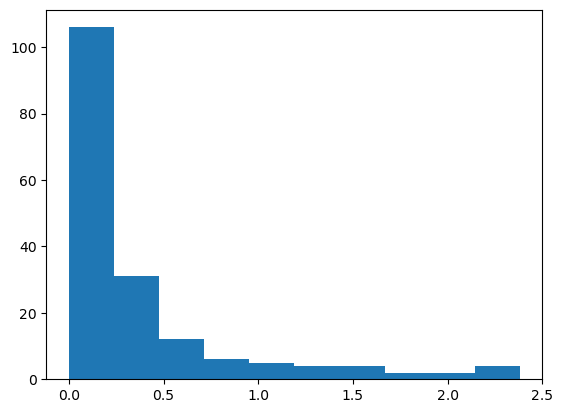

In [ ]:
plt.hist(evals)

In [ ]:
# Debug: GIF of local representative — 8 lowest Hessian modes during compression
# Layout: 2 rows × 4 columns; each subpanel = one mode; frames = compression steps
# Rest lengths derived from positions0 (not np.ones) to get correct positive eigenvalues.

import matplotlib.animation as animation

_traj_l0     = [l_rep["si0_traj"][t] for t in range(len(l_rep["si0_traj"]))]
_stiff_l     = np.array(l_rep["stiffnesses"])
_edges_l     = np.array(l_rep["edges"], dtype=int)
_fdofs_l     = np.array(l_rep["fdofs"], dtype=int)
_pos0_l      = np.array(l_rep["si0_traj"][0])
_N_l         = _pos0_l.shape[0]
_B_l         = build_incidence_matrix(_edges_l, _N_l)
_eq_lens_l   = np.linalg.norm(_B_l @ _pos0_l, axis=1)
_strain_vals_l = np.linspace(0, LOCAL_MAX_STRAIN, len(_traj_l0))

_N_MODES = 8
_fps_l   = 8

_fig_dl, _axes_dl = plt.subplots(2, 4, figsize=(16, 8))
_axes_flat_l = _axes_dl.ravel()

def _update_l(t):
    pos = np.array(_traj_l0[t])
    vals, vecs_T = hessian_modes(pos, _stiff_l, _eq_lens_l, _edges_l, _fdofs_l)
    for mi in range(_N_MODES):
        ax = _axes_flat_l[mi]
        ax.clear()
        draw_network(ax, pos, _edges_l, _stiff_l, cmap="Greys", alpha=0.35)
        evec_full = np.zeros(2 * pos.shape[0])
        evec_full[_fdofs_l] = vecs_T[mi]
        draw_mode_quiver(ax, pos, evec_full, color=f"C{mi}", alpha=0.85)
        ax.set_title(f"Mode {mi+1}  λ={vals[mi]:.3g}", fontsize=8)
        ax.axis("off")
    _fig_dl.suptitle(f"Local rep (task {LOCAL_TASK_ID}) — strain {_strain_vals_l[t]:.3f}",
                     fontsize=11)
    return []

def _init_l():
    for ax in _axes_flat_l:
        ax.clear()
    return []

_anim_l = animation.FuncAnimation(
    _fig_dl, _update_l, init_func=_init_l,
    frames=len(_traj_l0), interval=1000 // _fps_l, blit=False
)
_gif_path_l = FIGURE_OUT_DIR / "debug_local_8modes.gif"
_writer_l = animation.PillowWriter(fps=_fps_l)
_anim_l.save(str(_gif_path_l), writer=_writer_l)
plt.close(_fig_dl)
print(f"Debug GIF saved → {_gif_path_l}")


Debug GIF saved → /Users/fmartins/Library/CloudStorage/Box-Box/PhD/nonlinear_mech_nets/figure_data/allfigs/debug_local_8modes.gif


## Debug: Response Trajectories

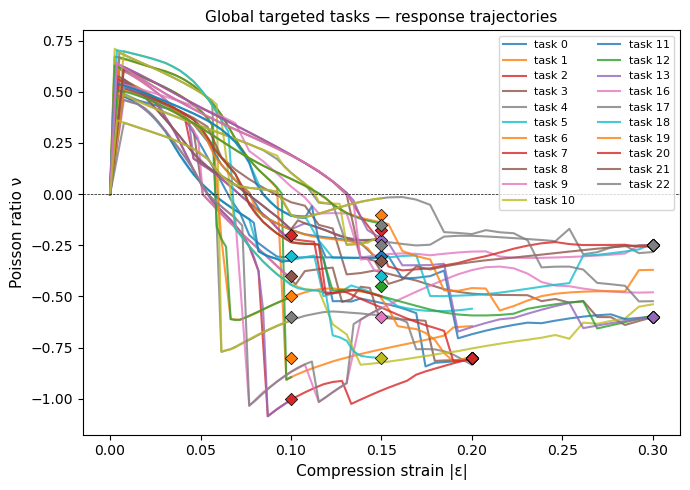

In [ ]:
# Debug: global targeted task response curves (Poisson ratio vs compression strain)

fig_dbr, ax_dbr = plt.subplots(figsize=(7, 5))

for task_id in GLOBAL_RESPONSE_TASKS:
    try:
        net_resp, bnd_resp, cfg_resp = load_global_network(task_id, 0, data_dir=TARGETED_DIR)
    except Exception:
        continue
    comp_strains_resp = cfg_resp["compression_strains"]
    target_pois_resp  = cfg_resp["target_poisson_ratios"]
    task_color = None
    for si, (cs, tp) in enumerate(zip(comp_strains_resp, target_pois_resp)):
        traj_resp = compute_global_traj(net_resp, cs, bnd_resp, n_steps=40)
        strains, nus = poisson_ratio_along_traj(traj_resp, bnd_resp)
        label = f"task {task_id}" if si == 0 else None
        line, = ax_dbr.plot(np.abs(strains), nus, alpha=0.8, label=label)
        if task_color is None:
            task_color = line.get_color()
        ax_dbr.scatter([np.abs(cs)], [tp], marker="D", s=40, color=task_color,
                       zorder=5, linewidths=0.5, edgecolors="k")

ax_dbr.set_xlabel("Compression strain |ε|", fontsize=11)
ax_dbr.set_ylabel("Poisson ratio ν", fontsize=11)
ax_dbr.set_title("Global targeted tasks — response trajectories", fontsize=11)
ax_dbr.legend(fontsize=8, ncol=2)
ax_dbr.axhline(0, c="k", lw=0.5, ls="--")
plt.tight_layout()
plt.show()
